In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)


In [68]:
od_agg = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\modeling\od_agg.csv", encoding='utf-8-sig')
stay_agg = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\modeling\stay_agg.csv", encoding='utf-8-sig')

In [69]:
od_agg['dest_purpose_grp'].unique()

array(['기타', '여행', '쇼핑여가', '업무', '귀가', '학업'], dtype=object)

## 유입: OD

### 함수

In [359]:
THEME = {
    "grid": "#D9DDE3",
    "text": "#1F2D3D",
    "peak": "#2F3A4A",

    # age (참고: 필요하면 추가/수정)
    "age_colors": {
        "adole":  "#639CD8",
        "young":  "#F17474",
        "middle": "#54A24B",
        "senior": "#F58518",
    },

    # 목적(OD)
    "purpose_colors": {
        "귀가":     "#639CD8", 
        "업무":     "#F17474",
        "학업":     "#54A24B",
        "쇼핑여가": "#ECA82C",
        "여행":     "#F58518",
        "기타":     "#9DAAB6",
    },

    # modal(OD) - 데이터에 맞게 필요시 수정
    "modal_colors": {
        "차량": "#F17474",
        "시내버스": "#54A24B",
        "지하철": "#72B7B2",
        "도보": "#ECA82C",
        "기타": "#9DAAB6",
        "철도": "#F58518",
        "시외고속버스": "#FFFF8E",
        "항공기":"#FC5CFF"
    }
}

MODAL_MAP = {
    0: "차량",
    1: "시내버스",
    2: "지하철",
    3: "도보",
    4: "기타",
    5: "철도",
    6: "시외고속버스",
    7: "항공기",
}


def set_ppt_style(font_family="Malgun Gothic", base_size=12):
    plt.rcParams["font.family"] = font_family
    plt.rcParams["font.size"] = base_size
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["figure.dpi"] = 160
    plt.rcParams["savefig.dpi"] = 300

def _clean_axes(ax):
    ax.grid(True, axis="y", color=THEME["grid"], alpha=0.6, linestyle="--", linewidth=0.8)
    ax.grid(True, axis="x", color=THEME["grid"], alpha=0.35, linestyle="--", linewidth=0.6)
    ax.set_axisbelow(True)

def _fmt_thousands(x, pos):
    return f"{int(x):,}"

def _time_label(h):
    return f"{int(h):02d}:00"

def _ensure_cols_od(df):
    need = {"dest_hdong_cd","weekday","time_bin","age_grp","dest_purpose_grp","modal","od_cnts_sum"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"od_agg에 필요한 컬럼이 없습니다: {sorted(miss)}")

def _subplot_grid(n):
    """요구한 규칙 그대로."""
    if n <= 0:
        return (1, 1)
    if n == 1:
        return (1, 1)
    if n == 2:
        return (1, 2)
    if n == 3:
        return (1, 3)
    if n == 4:
        return (2, 2)
    if n == 5:
        return (2, 3)  # 요구사항
    # 6개 이상은 3열 기준으로 확장(안 쓸 가능성 높지만 안전)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    return (nrows, ncols)

def _filter_market_od(od_agg, dest_hdong_cd=4713035000):
    _ensure_cols_od(od_agg)
    df = od_agg[od_agg["dest_hdong_cd"].astype(str) == str(dest_hdong_cd)].copy()
    if df.empty:
        raise ValueError(f"dest_hdong_cd == {dest_hdong_cd} 조건에서 데이터가 없습니다.")
    df["time_bin"] = df["time_bin"].astype(int)
    return df

WEEKDAY_ORDER = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]


### 유입 수단 파이차트

In [360]:
def plot_od_modal_pie(
    od_agg,
    dest_hdong_cd=4713035000,
    title="유입 수단 비율",
    figsize=(6.8, 4.8),
    top_label_n=2  # ← 추가: 라벨 표시 개수
):
    df = _filter_market_od(od_agg, dest_hdong_cd)

    df = df.copy()
    df["modal_name"] = df["modal"].map(MODAL_MAP).fillna("기타")

    s = (df.groupby("modal_name")["od_cnts_sum"]
           .sum()
           .sort_values(ascending=False))

    labels_all = s.index.tolist()
    values = s.values

    # ✅ Top-N만 라벨 표시
    top_label_n = max(1, min(int(top_label_n), len(labels_all)))
    top_labels = set(labels_all[:top_label_n])
    labels = [lbl if lbl in top_labels else "" for lbl in labels_all]

    colors = [
        THEME["modal_colors"].get(lbl, THEME["modal_colors"].get("기타", "#9DAAB6"))
        for lbl in labels_all
    ]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontweight="bold", color=THEME["text"])

    def autopct(pct):
        total = values.sum()
        val = int(round(pct * total / 100.0))
        # 퍼센트 라벨은 너무 많아지면 지저분해지니 5% 이상만
        return f"{pct:.1f}%\n({val:,})" if pct > 5 else ""

    ax.pie(
        values,
        labels=labels,
        colors=colors,
        startangle=90,
        counterclock=False,
        autopct=autopct,
        pctdistance=0.72,
        labeldistance=1.05,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.2)
    )

    ax.axis("equal")
    plt.tight_layout()
    return fig, ax


In [361]:
od_agg['modal'].value_counts()/od_agg['modal'].value_counts().sum()

modal
 0    0.623520
 1    0.232097
 4    0.104589
 3    0.033569
 5    0.003911
 2    0.001517
 7    0.000771
-1    0.000026
Name: count, dtype: float64

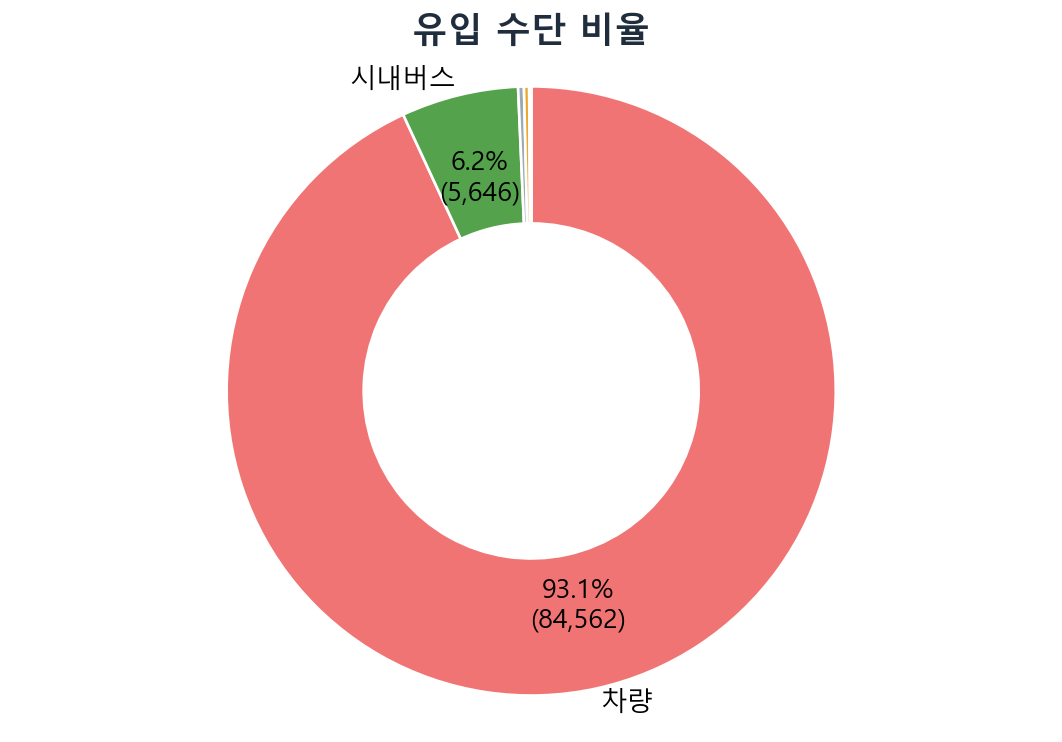

In [362]:
set_ppt_style(base_size=12)
fig, _ = plot_od_modal_pie(od_agg, 
                           dest_hdong_cd=4713035000, 
                           top_label_n=2)
plt.show()

### 유입인구 나이별 비율 파이차트

In [363]:
def plot_od_age_pie(
    od_agg,
    dest_hdong_cd=4713035000,
    title="유입인구(연령대) 비율",
    figsize=(6.8, 4.8),
    top_label_n=2
):
    df = _filter_market_od(od_agg, dest_hdong_cd).copy()

    s = (df.groupby("age_grp")["od_cnts_sum"]
           .sum()
           .sort_values(ascending=False))

    labels_all = s.index.tolist()
    values = s.values

    # Top-N만 라벨 표시
    top_label_n = max(1, min(int(top_label_n), len(labels_all)))
    top_labels = set(labels_all[:top_label_n])
    labels = [lbl if lbl in top_labels else "" for lbl in labels_all]

    # 색상: 있으면 age_colors 쓰고 없으면 기본
    colors = [THEME.get("age_colors", {}).get(lbl, "#9DAAB6") for lbl in labels_all]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontweight="bold", color=THEME["text"])

    def autopct(pct):
        total = values.sum()
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})" if pct > 5 else ""

    ax.pie(
        values,
        labels=labels,
        colors=colors,
        startangle=90,
        counterclock=False,
        autopct=autopct,
        pctdistance=0.72,
        labeldistance=1.05,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.2)
    )
    ax.axis("equal")
    plt.tight_layout()
    return fig, ax


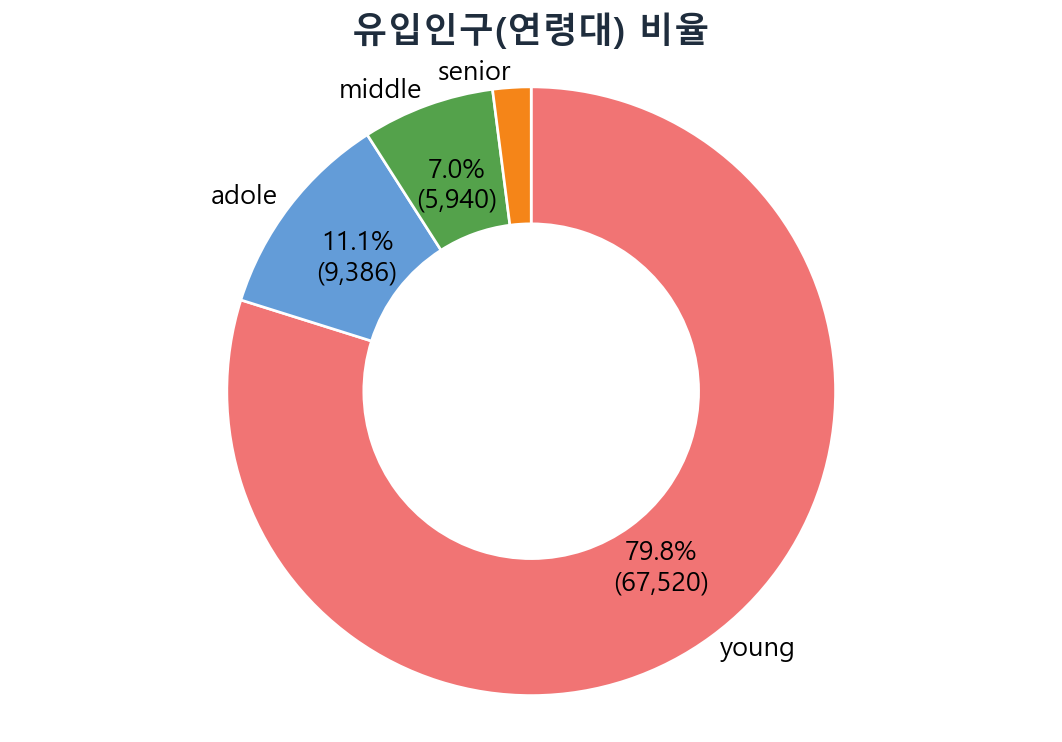

In [364]:
set_ppt_style(base_size=12)
fig, ax = plot_od_age_pie(od_agg[od_agg['modal'] == 0], 
                          dest_hdong_cd=4713035000, 
                          top_label_n=4)
plt.show()

### 연령대 x 유입 목적 별 파이차트

In [365]:
def plot_od_purpose_pies_by_age(
    od_agg,
    dest_hdong_cd=4713035000,
    ages=("adole","young","middle","senior"),
    purpose_list=None,          # ← 추가: 보고 싶은 목적만 선택
    title="연령대별 유입 목적 비율",
    figsize_unit=(5.2, 4.0),
    top_label_n=2,              # 각 파이에서 라벨 표시 개수
    min_pct_label=5.0           # autopct 표시 최소 퍼센트
):
    df = _filter_market_od(od_agg, dest_hdong_cd).copy()
    ages = list(ages)

    # 목적 필터
    if purpose_list is not None:
        df = df[df["dest_purpose_grp"].isin(purpose_list)].copy()

    # 레이아웃 결정
    n = len(ages)
    if n == 1:
        nrows, ncols = 1, 1
    elif n == 2:
        nrows, ncols = 1, 2
    elif n == 3:
        nrows, ncols = 1, 3
    else:
        nrows, ncols = 2, 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows),
        squeeze=False
    )
    fig.suptitle(title, y=1.03, fontsize=15, fontweight="bold", color=THEME["text"])
    axes_flat = axes.flatten()

    for i, age in enumerate(ages):
        ax = axes_flat[i]
        sub = df[df["age_grp"] == age].copy()
        if sub.empty:
            ax.axis("off")
            continue

        s = (sub.groupby("dest_purpose_grp")["od_cnts_sum"]
               .sum()
               .sort_values(ascending=False))

        labels_all = s.index.tolist()
        values = s.values

        # Top-N 목적만 라벨 표시
        top_n = max(1, min(int(top_label_n), len(labels_all)))
        top_labels = set(labels_all[:top_n])
        labels = [lbl if lbl in top_labels else "" for lbl in labels_all]

        colors = [
            THEME["purpose_colors"].get(lbl, THEME["purpose_colors"].get("기타", "#9DAAB6"))
            for lbl in labels_all
        ]

        def autopct(pct):
            total = values.sum()
            val = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n({val:,})" if pct >= min_pct_label else ""

        ax.pie(
            values,
            labels=labels,
            colors=colors,
            startangle=90,
            counterclock=False,
            autopct=autopct,
            pctdistance=0.72,
            labeldistance=1.05,
            wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.2)
        )
        ax.set_title(f"age_grp = {age}", fontweight="bold", color=THEME["text"], pad=10)
        ax.axis("equal")

    # 남는 축 제거
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes


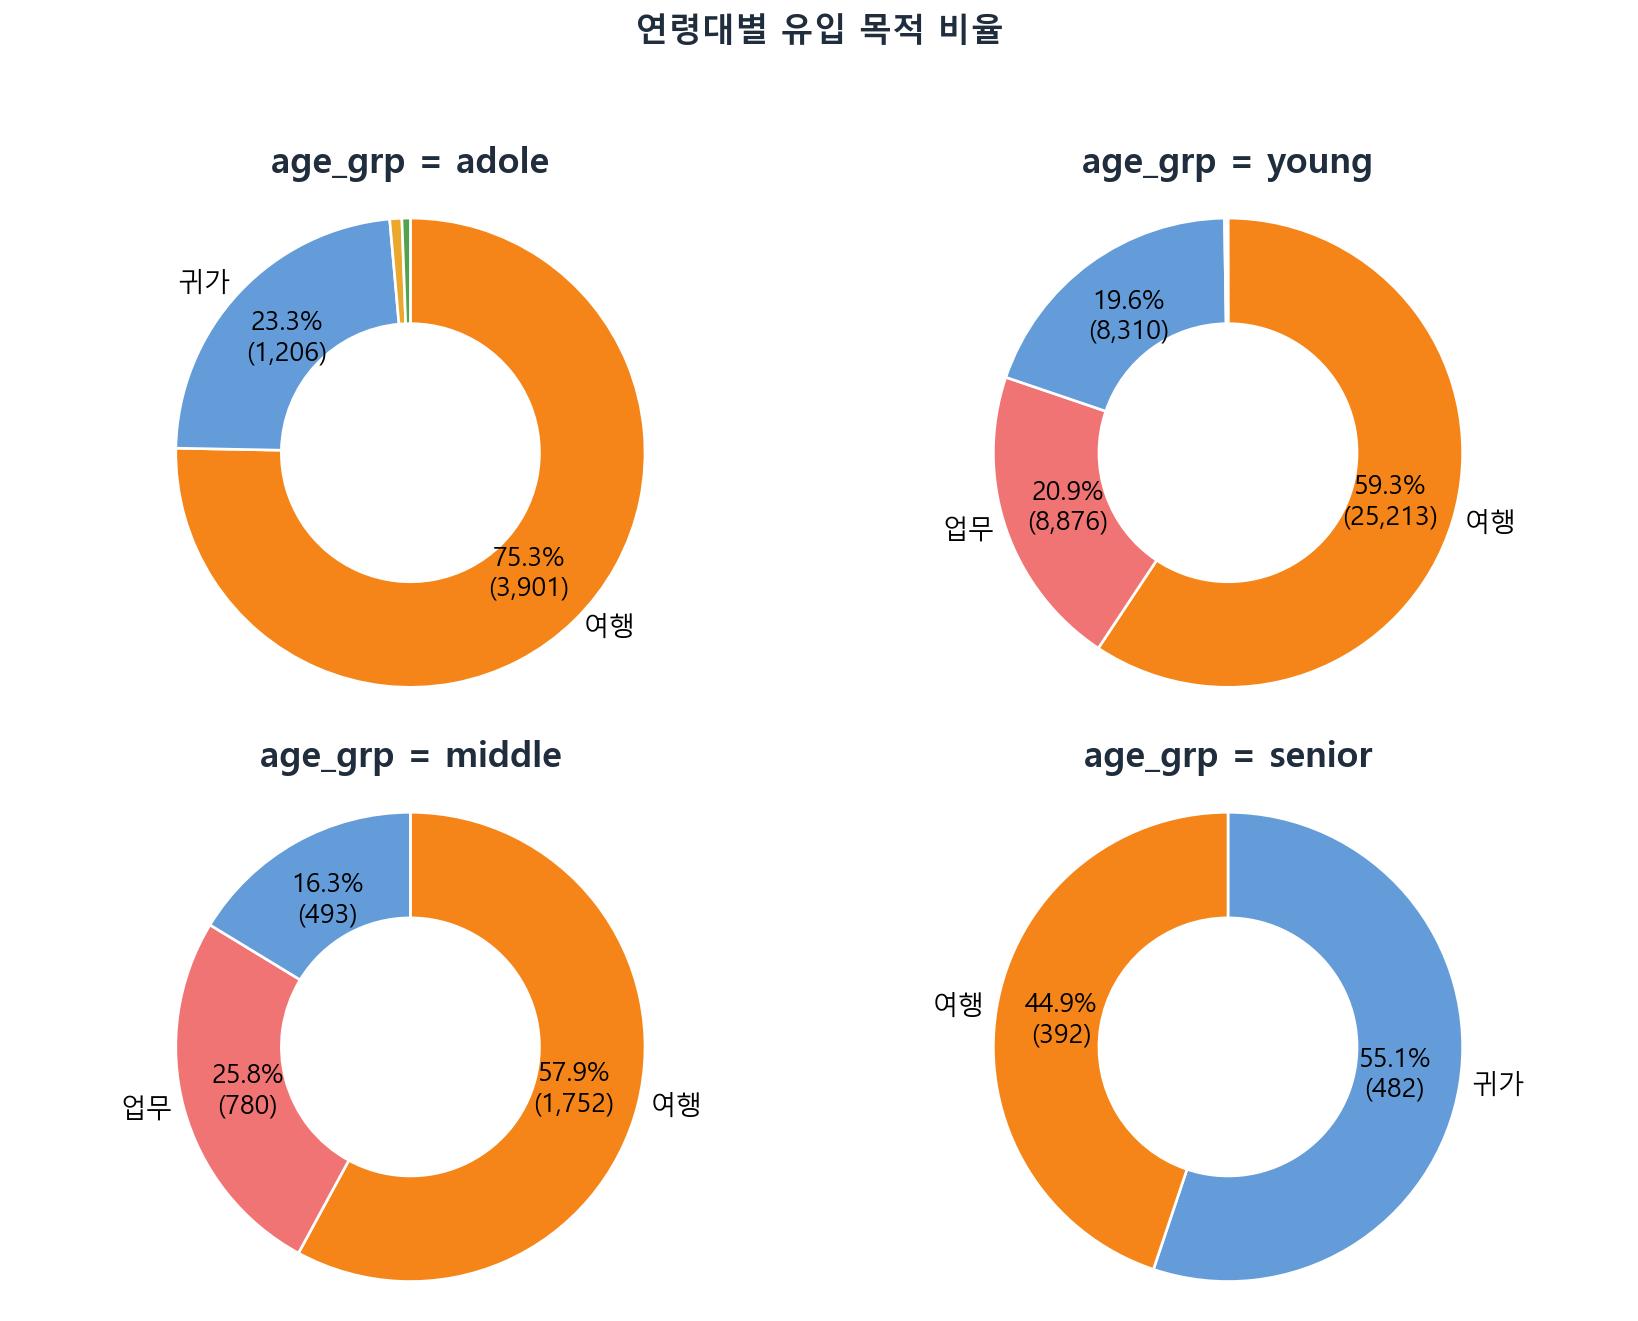

In [366]:
set_ppt_style(base_size=12)

fig, axes = plot_od_purpose_pies_by_age(
    od_agg,
    dest_hdong_cd=4713035000,
    title="연령대별 유입 목적 비율",
    ages=("adole","young","middle","senior"),
    purpose_list=["여행", "귀가", "업무", "쇼핑여가", "학업"],
    top_label_n=2,
    min_pct_label=5.0
)
plt.show()

### 나이 x 유입 목적 별: 막대 그래프

In [367]:
def plot_od_age_purpose_stacked(od_agg, dest_hdong_cd=4713035000,
                                ages=("adole","young","middle","senior"),
                                purpose_list=None,
                                title=None, figsize=(9.2, 5.0),
                                min_ratio_label=0.07):
    df = _filter_market_od(od_agg, dest_hdong_cd)

    df = df[df["age_grp"].isin(list(ages))].copy()
    if purpose_list is not None:
        df = df[df["dest_purpose_grp"].isin(list(purpose_list))].copy()
    if df.empty:
        raise ValueError("조건(ages/purpose_list)에 맞는 데이터가 없습니다.")

    pv = (df.groupby(["age_grp","dest_purpose_grp"])["od_cnts_sum"]
            .sum().unstack(fill_value=0.0))
    # 연령 순서
    age_order = [a for a in ["adole","young","middle","senior"] if a in pv.index]
    pv = pv.reindex(age_order).dropna(how="all")

    # 목적 순서(보기좋게)
    default_order = ["귀가","업무","학업","쇼핑여가","여행","기타"]
    col_order = [c for c in default_order if c in pv.columns] + [c for c in pv.columns if c not in default_order]
    pv = pv[col_order]

    totals = pv.sum(axis=1).replace(0, np.nan)

    if title is None:
        title = "나이 × 유입목적 : 유입인구수 & 목적 비율" if purpose_list is None \
                else f"나이 × 유입목적(선택: {', '.join(purpose_list)}) : 유입인구수 & 목적 비율"

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontweight="bold", color=THEME["text"])

    x = np.arange(len(pv.index))
    bottom = np.zeros(len(pv.index))

    for col in pv.columns:
        vals = pv[col].to_numpy()
        color = THEME["purpose_colors"].get(col, "#9DAAB6")

        bars = ax.bar(x, vals, bottom=bottom, color=color, width=0.62,
                      edgecolor="white", linewidth=0.9, label=col)

        ratios = vals / totals.to_numpy()
        for i, (b, r, v) in enumerate(zip(bars, ratios, vals)):
            if np.isnan(r) or v <= 0 or r < min_ratio_label:
                continue
            ax.text(b.get_x()+b.get_width()/2, bottom[i] + v/2,
                    f"{r*100:.0f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold", color="white")

        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(a) for a in pv.index])
    ax.set_xlabel("age_grp")
    ax.set_ylabel("od_cnts_sum")
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
    _clean_axes(ax)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    return fig, ax


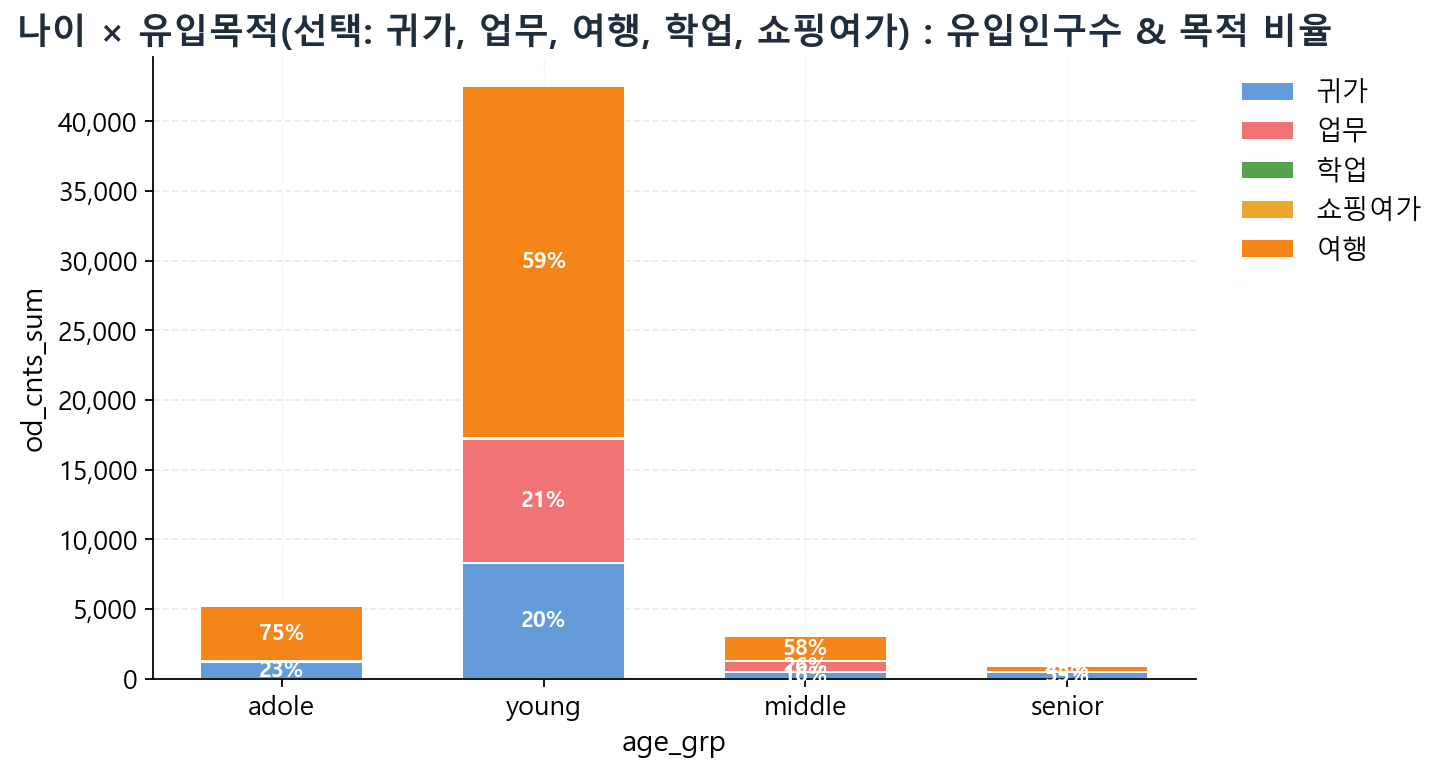

In [368]:
set_ppt_style(base_size=12)
fig, _ = plot_od_age_purpose_stacked(
    od_agg, dest_hdong_cd=4713035000,
    ages=('adole', 'young', "middle","senior"),
    purpose_list=['귀가', '업무', '여행', '학업', '쇼핑여가']
)
plt.show()


### 시간 x 유입 목적 별: 선 그래프

In [369]:
def plot_od_time_by_purpose_lines(od_agg, dest_hdong_cd=4713035000,
                                  purpose_list=None,
                                  title="시간대별 유입 추이(목적별)",
                                  figsize=(9.2, 5.0),
                                  fill_alpha=0.10):
    df = _filter_market_od(od_agg, dest_hdong_cd)

    if purpose_list is not None:
        df = df[df["dest_purpose_grp"].isin(list(purpose_list))].copy()
    if df.empty:
        raise ValueError("조건(purpose_list)에 맞는 데이터가 없습니다.")

    pv = (df.groupby(["dest_purpose_grp","time_bin"])["od_cnts_sum"]
            .sum().reset_index())
    pv["time_bin"] = pv["time_bin"].astype(int)

    purposes = pv["dest_purpose_grp"].unique().tolist()
    # 보기 좋은 순서
    default_order = ["귀가","업무","학업","쇼핑여가","여행","기타"]
    purposes = [p for p in default_order if p in purposes] + [p for p in purposes if p not in default_order]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontweight="bold", color=THEME["text"])

    for p in purposes:
        sub = pv[pv["dest_purpose_grp"] == p].sort_values("time_bin")
        x = sub["time_bin"].to_numpy()
        y = sub["od_cnts_sum"].to_numpy()
        c = THEME["purpose_colors"].get(p, "#9DAAB6")

        ax.plot(x, y, color=c, linewidth=2.4, marker="o", markersize=4.2, label=p)
        ax.fill_between(x, y, 0, color=c, alpha=fill_alpha)

    xticks = sorted(pv["time_bin"].unique())
    ax.set_xticks(xticks)
    ax.set_xticklabels([_time_label(t) for t in xticks], rotation=45, ha="right")
    ax.set_xlabel("time_bin")
    ax.set_ylabel("od_cnts_sum")
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
    _clean_axes(ax)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    return fig, ax

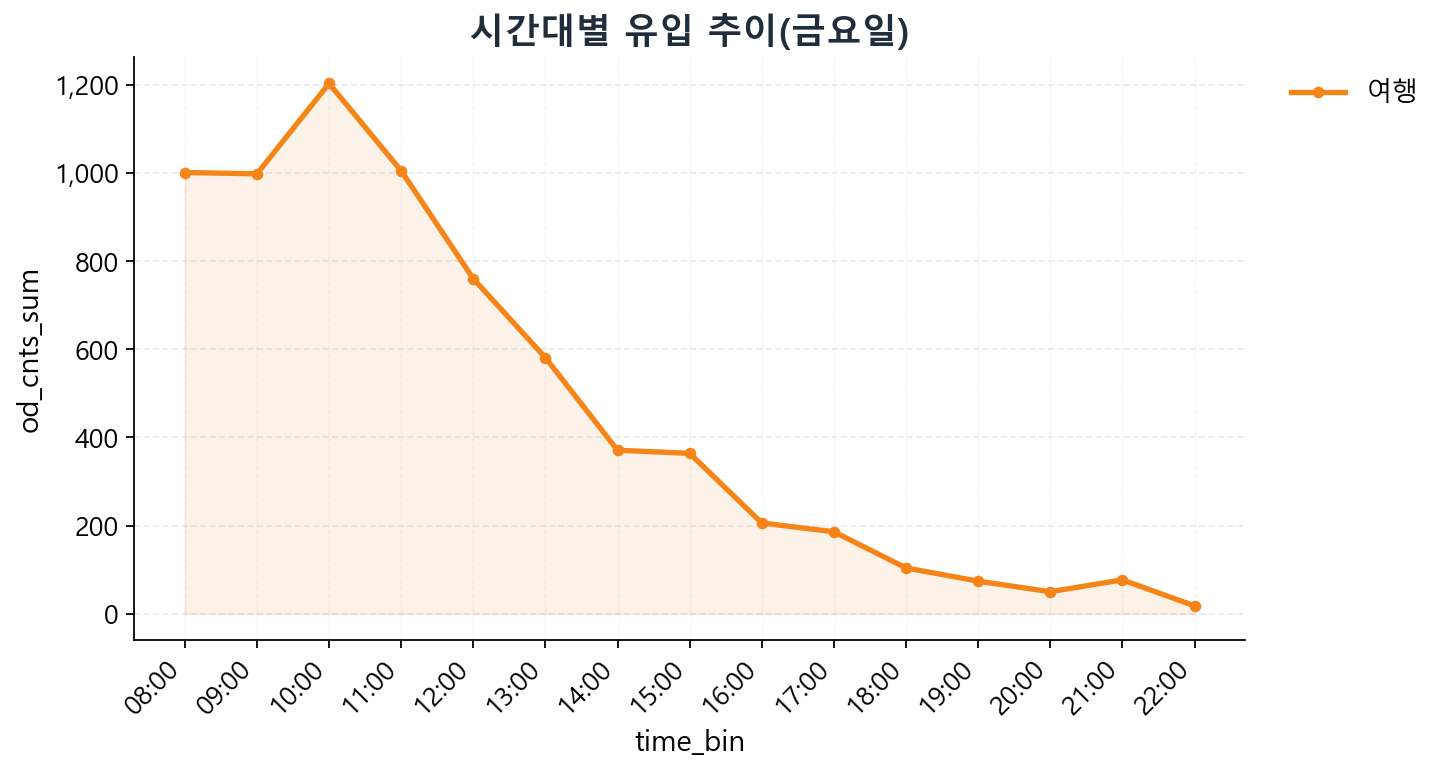

In [370]:
set_ppt_style(base_size=12)
fig, _ = plot_od_time_by_purpose_lines(
    od_agg[(od_agg['weekday'] == 'Fri') & (od_agg['age_grp'] == 'young')],
    title="시간대별 유입 추이(금요일)", 
    dest_hdong_cd=4713035000,
    purpose_list=["여행"]  # 필요 시
)
plt.show()

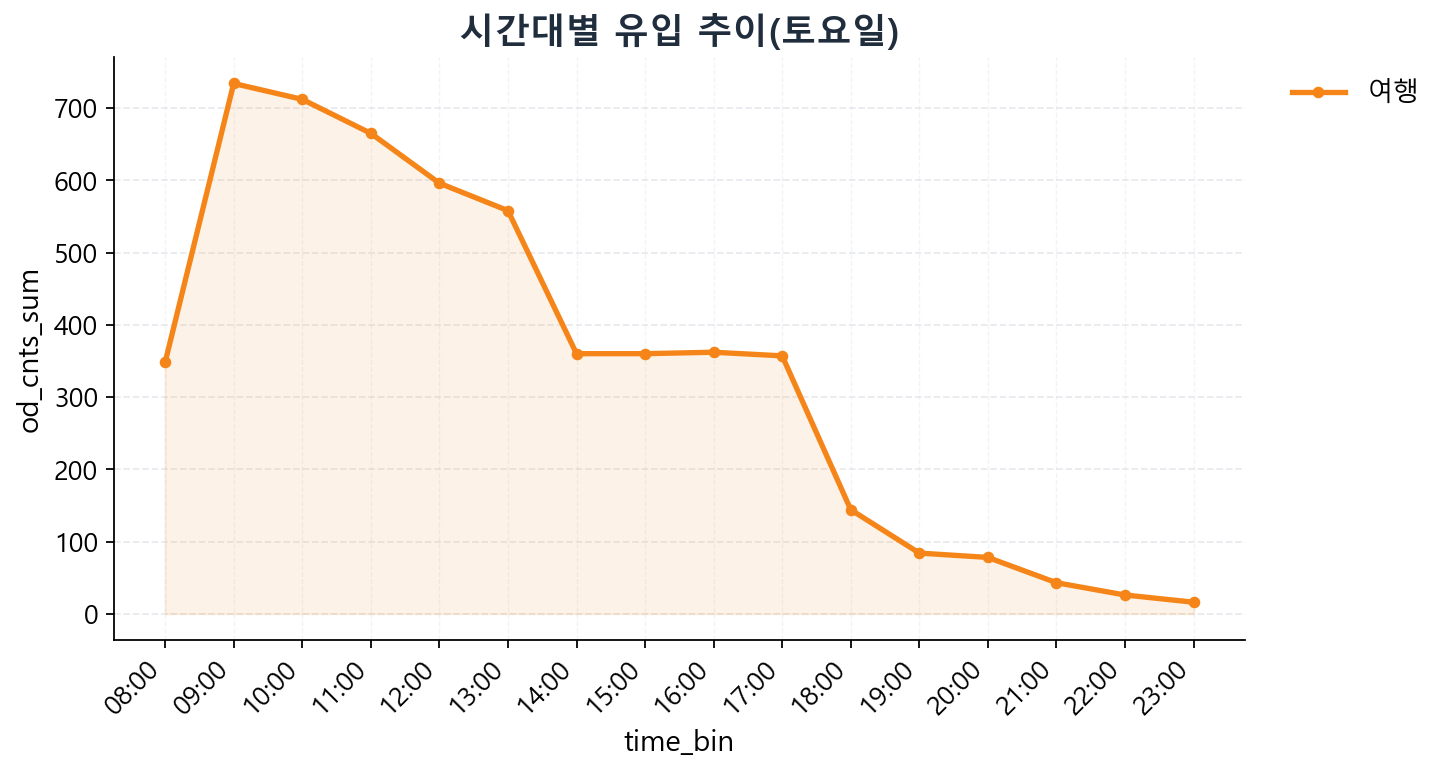

In [371]:
set_ppt_style(base_size=12)
fig, _ = plot_od_time_by_purpose_lines(
    od_agg[(od_agg['weekday'] == 'Sat') & (od_agg['age_grp'] == 'young')], 
    title="시간대별 유입 추이(토요일)", 
    dest_hdong_cd=4713035000,
    purpose_list=["여행"]  # 필요 시
)
plt.show()

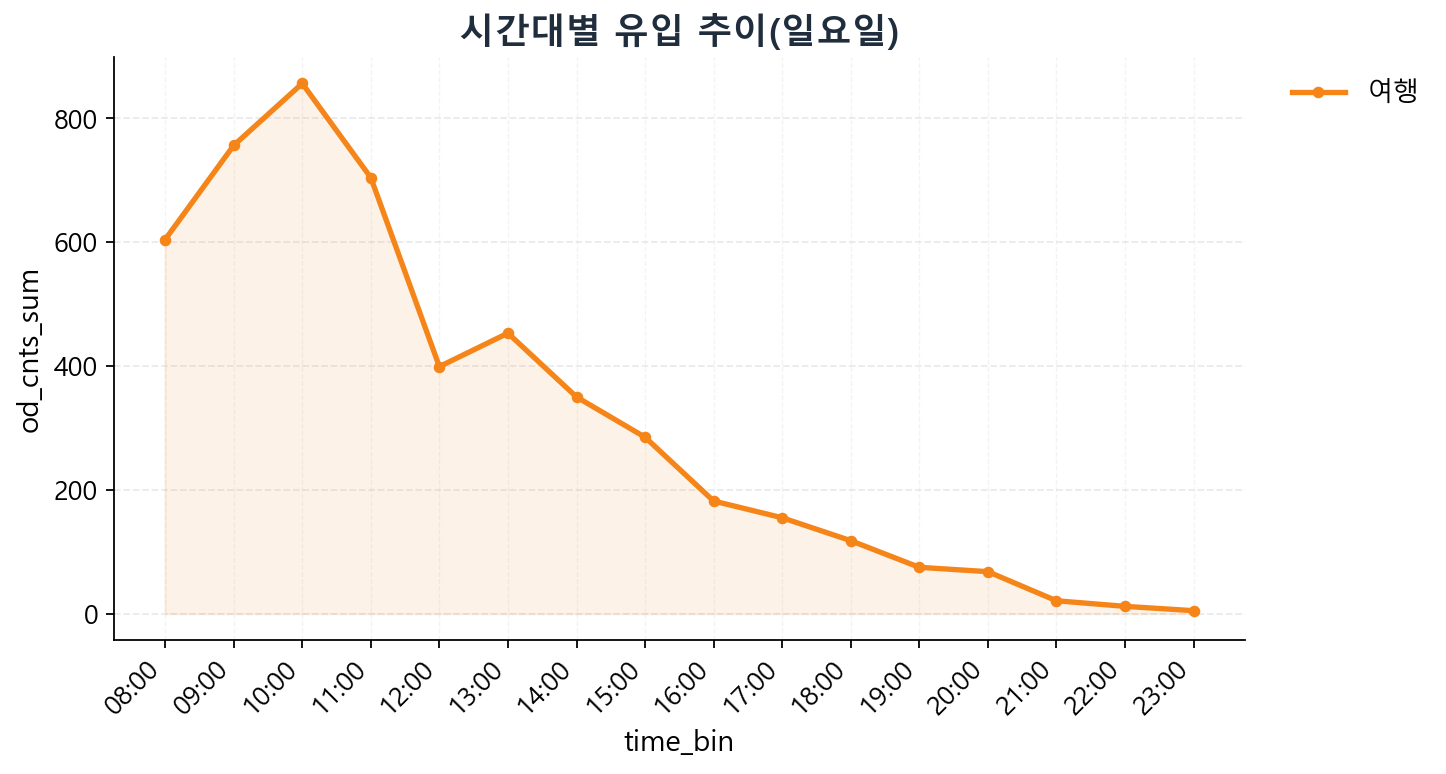

In [372]:
set_ppt_style(base_size=12)
fig, _ = plot_od_time_by_purpose_lines(
    od_agg[(od_agg['weekday'] == 'Sun') & (od_agg['age_grp'] == 'young')], 
    title="시간대별 유입 추이(일요일)", 
    dest_hdong_cd=4713035000,
    purpose_list=["여행"]  # 필요 시
)
plt.show()

### 요일 x 유입 목적 별: 막대 그래프

In [373]:
def plot_od_weekday_by_purpose_bars(od_agg, dest_hdong_cd=4713035000,
                                    purpose_list=None,
                                    title_prefix="요일별 유입(목적: ",
                                    figsize_unit=(5.2, 4.0)):
    df = _filter_market_od(od_agg, dest_hdong_cd)

    if purpose_list is None:
        purposes = df["dest_purpose_grp"].unique().tolist()
    else:
        purposes = list(purpose_list)

    # 순서 정리
    default_order = ["귀가","업무","학업","쇼핑여가","여행","기타"]
    purposes = [p for p in default_order if p in purposes] + [p for p in purposes if p not in default_order]

    n = len(purposes)
    nrows, ncols = _subplot_grid(n)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows), squeeze=False)

    axes_flat = axes.flatten()

    for i, p in enumerate(purposes):
        ax = axes_flat[i]
        sub = df[df["dest_purpose_grp"] == p].copy()
        g = (sub.groupby("weekday")["od_cnts_sum"].sum()
              .reindex(WEEKDAY_ORDER).dropna())

        xlabels = g.index.tolist()
        y = g.values
        x = np.arange(len(xlabels))
        c = THEME["purpose_colors"].get(p, "#9DAAB6")

        ax.bar(x, y, color=c, width=0.65, edgecolor="white", linewidth=0.9)
        ax.set_title(f"{title_prefix}{p})", fontweight="bold", color=THEME["text"])
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel("weekday")
        ax.set_ylabel("od_cnts_sum")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        _clean_axes(ax)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes


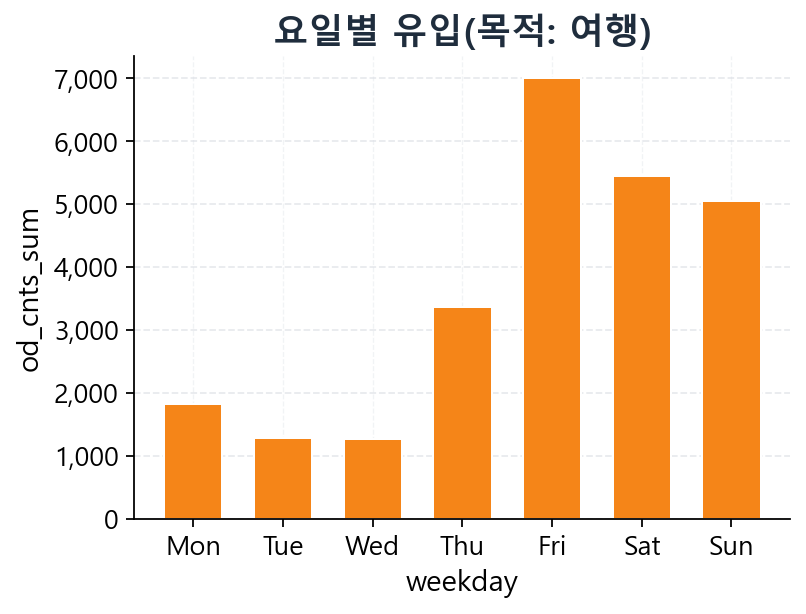

In [374]:
set_ppt_style(base_size=12)
fig, _ = plot_od_weekday_by_purpose_bars(
    od_agg[od_agg['age_grp'] == 'young'], 
    dest_hdong_cd=4713035000,
    purpose_list=['여행']
    #["여행","귀가","업무", "학업", "쇼핑여가"]
)
plt.show()

### 요일 x 나이대 별: 막대 그래프

In [375]:
def plot_od_weekday_by_age_bars(
    od_agg,
    dest_hdong_cd=4713035000,
    ages=("adole","young","middle","senior"),
    title="요일별 유입(나이대별)",
    figsize_unit=(5.2, 4.0),
    y_zoom="per_age",
    y_pad_ratio=0.10
):
    df = _filter_market_od(od_agg, dest_hdong_cd)
    ages = list(ages)

    n = len(ages)
    if n == 1: nrows, ncols = 1, 1
    elif n == 2: nrows, ncols = 1, 2
    elif n == 3: nrows, ncols = 1, 3
    elif n == 4: nrows, ncols = 2, 2
    else: nrows, ncols = 2, 3  # 안전장치

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows),
        squeeze=False
    )
    fig.suptitle(title, y=1.02, fontsize=15, fontweight="bold", color=THEME["text"])
    axes_flat = axes.flatten()

    g_all = (
        df[df["age_grp"].isin(ages)]
        .groupby(["age_grp","weekday"])["od_cnts_sum"]
        .sum()
        .reset_index()
    )

    # global y축 범위
    global_ylim = None
    if y_zoom == "global" and not g_all.empty:
        gmin, gmax = float(g_all["od_cnts_sum"].min()), float(g_all["od_cnts_sum"].max())
        pad = (gmax - gmin) * y_pad_ratio if gmax > gmin else max(gmin*0.01, 1.0)
        global_ylim = (gmin - pad, gmax + pad)

    for i, age in enumerate(ages):
        ax = axes_flat[i]
        sub = g_all[g_all["age_grp"] == age].copy()
        if sub.empty:
            ax.axis("off")
            continue

        s = (
            sub.set_index("weekday")["od_cnts_sum"]
            .reindex(WEEKDAY_ORDER)
            .dropna()
        )

        xlabels = s.index.tolist()
        x = np.arange(len(xlabels))
        y = s.values
        c = THEME["age_colors"].get(age, "#4C78A8")

        ax.bar(x, y, color=c, width=0.6, edgecolor="white", linewidth=0.9)

        # y축 줌
        if y_zoom == "per_age":
            ymin, ymax = float(y.min()), float(y.max())
            pad = (ymax - ymin) * y_pad_ratio if ymax > ymin else max(ymin*0.01, 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
        elif y_zoom == "global" and global_ylim is not None:
            ax.set_ylim(*global_ylim)

        ax.set_title(f"age_grp = {age}", fontweight="bold", color=THEME["text"])
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel("weekday")
        ax.set_ylabel("od_cnts_sum")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        _clean_axes(ax)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes


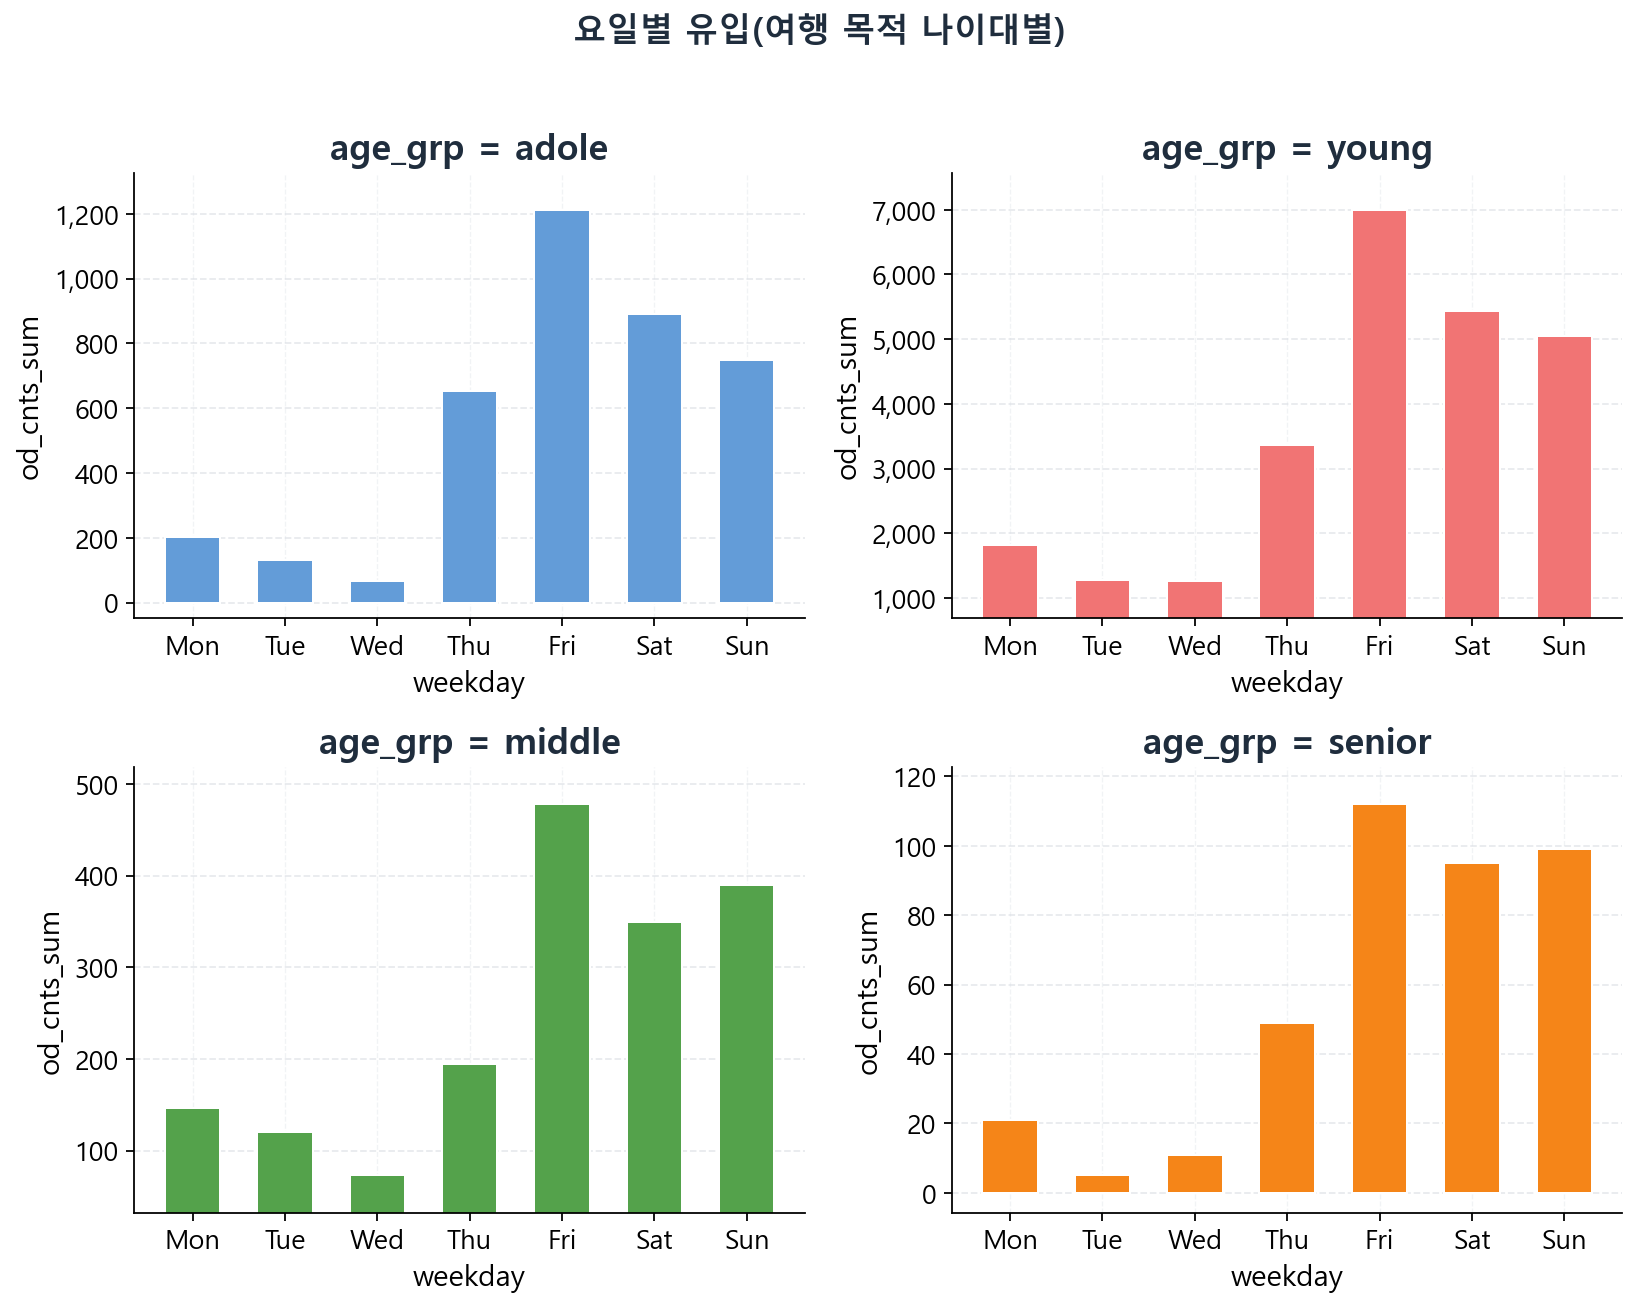

In [376]:
set_ppt_style(base_size=12)
fig, _ = plot_od_weekday_by_age_bars(
    od_agg[od_agg['dest_purpose_grp'] == '여행'],
    title="요일별 유입(여행 목적 나이대별)", 
    dest_hdong_cd=4713035000,
    ages=("adole", "young","middle","senior")
)
plt.show()

### 시간 x 나이대 별: 선 그래프

In [377]:
def plot_od_time_by_age_lines(od_agg, dest_hdong_cd=4713035000,
                              ages=("adole","young","middle","senior"),
                              title="시간대별 유입(나이대별)",
                              figsize_unit=(5.6, 4.2),
                              fill_alpha=0.12,
                              y_zoom="per_age",
                              y_pad_ratio=0.10,
                              show_peak=True):
    df = _filter_market_od(od_agg, dest_hdong_cd)
    ages = list(ages)

    # 2→1×2, 3→1×3, 4→2×2 규칙
    if len(ages) == 1:
        nrows, ncols = 1, 1
    elif len(ages) == 2:
        nrows, ncols = 1, 2
    elif len(ages) == 3:
        nrows, ncols = 1, 3
    else:
        nrows, ncols = 2, 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows), squeeze=False)
    fig.suptitle(title, y=1.03, fontsize=15, fontweight="bold", color=THEME["text"])
    axes_flat = axes.flatten()

    g_all = (df[df["age_grp"].isin(ages)]
             .groupby(["age_grp","time_bin"])["od_cnts_sum"].sum().reset_index())
    g_all["time_bin"] = g_all["time_bin"].astype(int)

    global_ylim = None
    if y_zoom == "global" and not g_all.empty:
        gmin, gmax = float(g_all["od_cnts_sum"].min()), float(g_all["od_cnts_sum"].max())
        pad = (gmax - gmin) * y_pad_ratio if gmax > gmin else max(gmin*0.01, 1.0)
        global_ylim = (gmin - pad, gmax + pad)

    for i, age in enumerate(ages):
        ax = axes_flat[i]
        sub = g_all[g_all["age_grp"] == age].sort_values("time_bin")
        if sub.empty:
            ax.axis("off")
            continue

        x = sub["time_bin"].to_numpy()
        y = sub["od_cnts_sum"].to_numpy()
        c = THEME["age_colors"].get(age, "#4C78A8")

        ax.plot(x, y, color=c, linewidth=2.6, marker="o", markersize=4.6)
        ax.fill_between(x, y, 0, color=c, alpha=fill_alpha)

        if show_peak:
            idx = int(np.argmax(y))
            x_peak, y_peak = int(x[idx]), float(y[idx])
            ax.axvline(x_peak, color=THEME["peak"], linewidth=1.0, alpha=0.55)
            ax.axhline(y_peak, color=THEME["peak"], linewidth=1.0, alpha=0.30)
            ax.scatter([x_peak], [y_peak], s=60, color=c, edgecolor="white", linewidth=1.0, zorder=5)
            ax.text(x_peak + 0.15, y_peak, f"peak {_time_label(x_peak)}\n{y_peak:,.0f}",
                    fontsize=10, fontweight="bold", color=THEME["text"], va="center")

        if y_zoom == "per_age":
            ymin, ymax = float(y.min()), float(y.max())
            pad = (ymax - ymin) * y_pad_ratio if ymax > ymin else max(ymin*0.01, 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
        elif y_zoom == "global" and global_ylim is not None:
            ax.set_ylim(*global_ylim)

        ax.set_title(f"age_grp = {age}", fontweight="bold", color=THEME["text"])
        xticks = sorted(np.unique(x))
        ax.set_xticks(xticks)
        ax.set_xticklabels([_time_label(t) for t in xticks], rotation=45, ha="right")
        ax.set_xlabel("time_bin")
        ax.set_ylabel("od_cnts_sum")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        _clean_axes(ax)

    for j in range(len(ages), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes


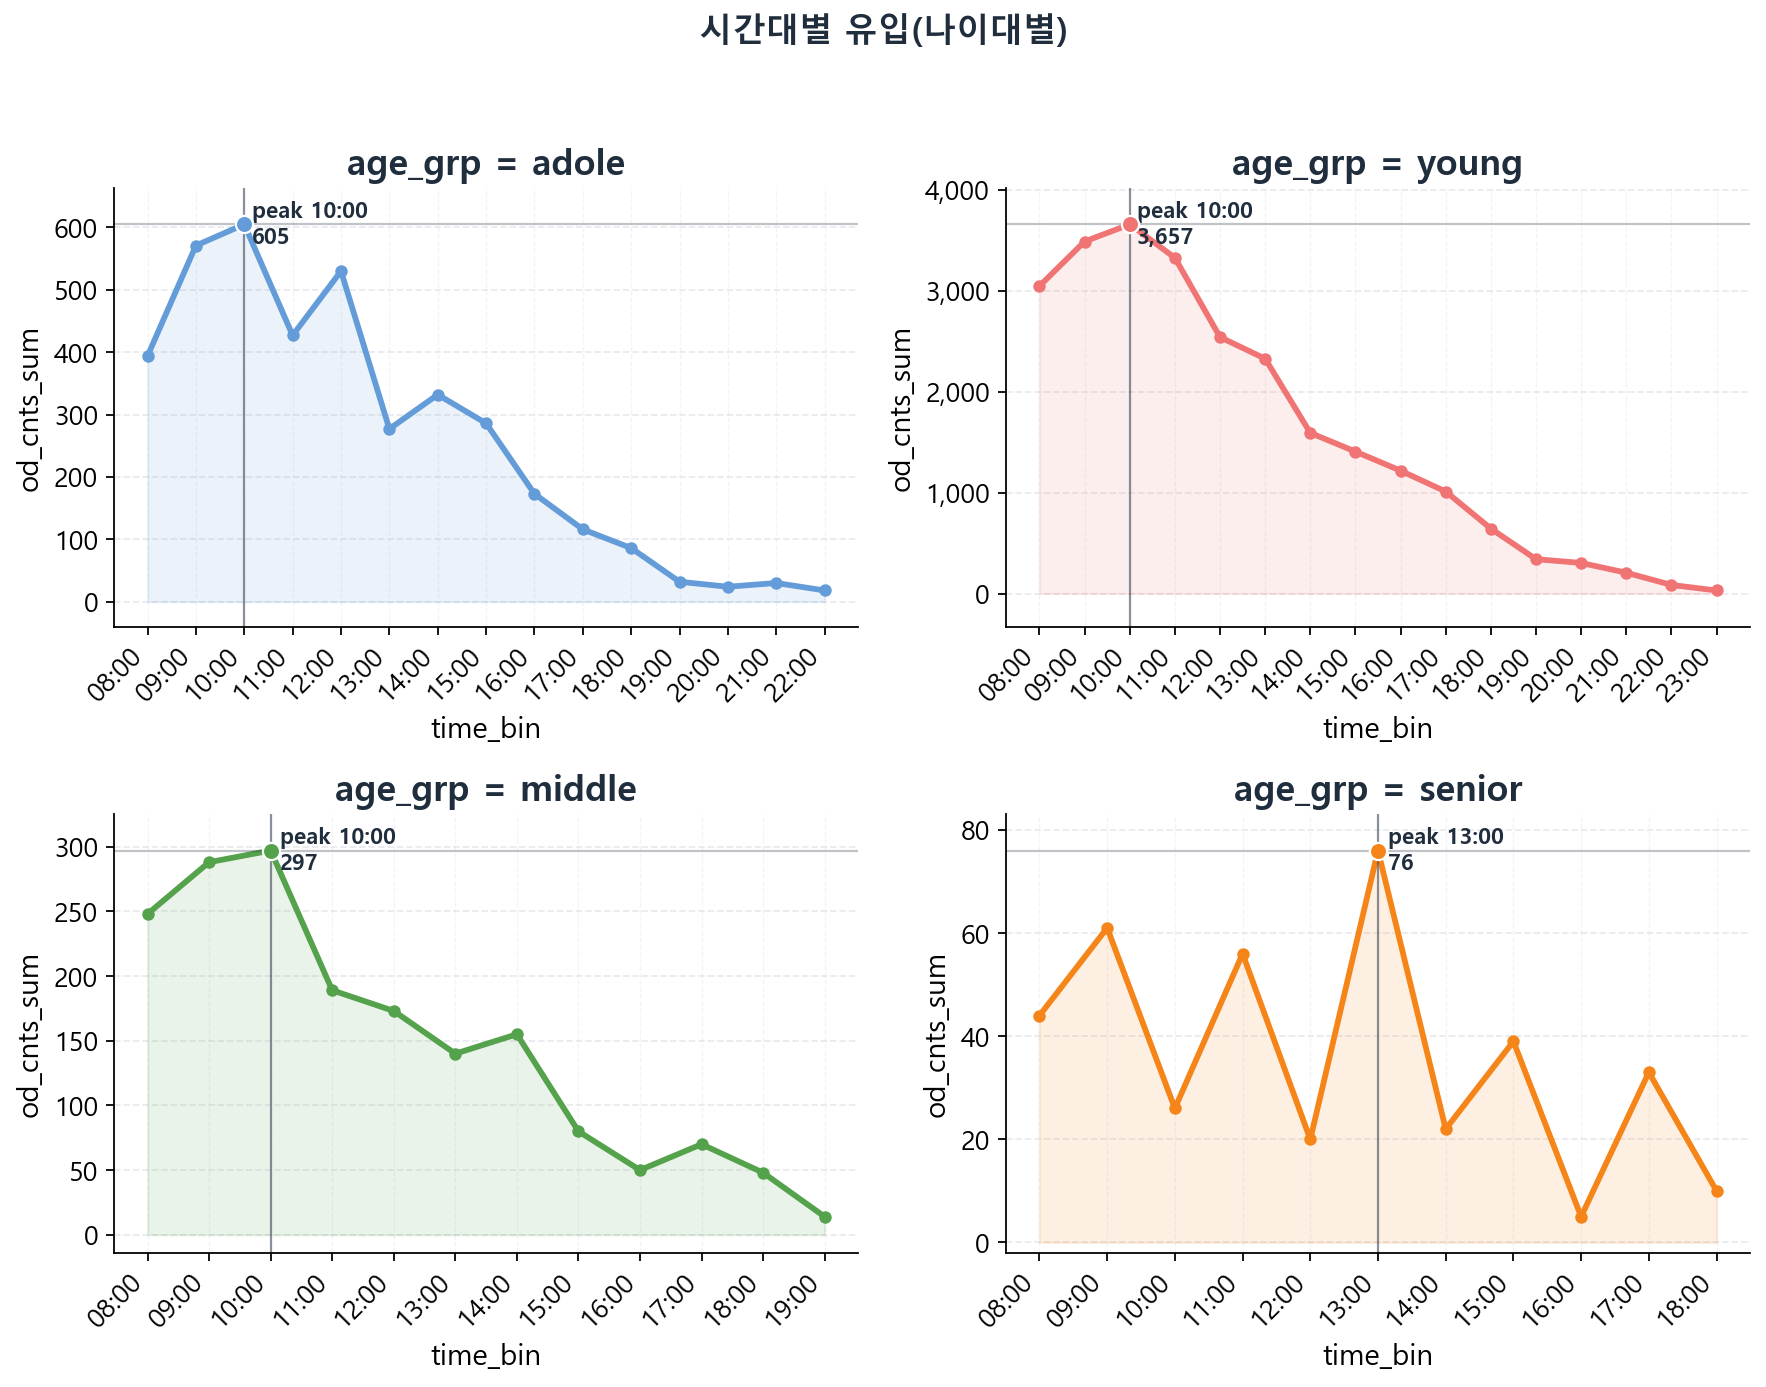

In [399]:
set_ppt_style(base_size=12)
fig, _ = plot_od_time_by_age_lines(
    od_agg[od_agg['dest_purpose_grp'] == '여행'], 
    dest_hdong_cd=4713035000,
    ages=("adole","young","middle","senior"),
    y_zoom="per_age"
)
plt.show()

## 체류: Stay

### 함수

In [379]:
THEME = {
    # 공통
    "grid": "#D9DDE3",
    "text": "#1F2D3D",
    "peak": "#2F3A4A",


    # 라인(연령대별) - 첨부 이미지처럼 '차분+대비' 조합
    "line_colors": {
        "adole":  "#639CD8",
        "young":  "#F17474",
        "middle": "#54A24B",
        "senior": "#F58518",
    },

    # 누적막대(목적별) - 목적이 6개라 대비가 필요
    "purpose_colors": {
        "귀가":     "#639CD8", 
        "업무":     "#F17474",
        "학업":     "#54A24B",
        "쇼핑여가": "#ECA82C",
        "여행":     "#F58518",
        "기타":     "#9DAAB6",
    },

    # 도넛(연령대) - 연령대별 동일 색을 쓰면 전체 톤이 통일됨
    "age_colors": {
        "adole":  "#639CD8",
        "young":  "#F17474",
        "middle": "#54A24B",
        "senior": "#F58518",
    }
}

WEEKDAY_ORDER = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

def _subplot_grid_purpose(n):
    """
    purpose용 배치 규칙(요청):
    2->1x2, 3->1x3, 4->2x2, 5->2x3
    그 외는 2x3 기준으로 확장
    """
    if n <= 1:
        return (1, 1)
    if n == 2:
        return (1, 2)
    if n == 3:
        return (1, 3)
    if n == 4:
        return (2, 2)
    if n == 5:
        return (2, 3)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    return (nrows, ncols)

def _subplot_grid_age(n):
    """
    age용 배치 규칙(요청):
    2->1x2, 3->1x3, 4->2x2
    """
    if n <= 1:
        return (1, 1)
    if n == 2:
        return (1, 2)
    if n == 3:
        return (1, 3)
    return (2, 2)


def _filter_hdong(df, hdong_cd=None):
    """
    hdong_cd가 주어지면 해당 행정동만 필터링
    """
    if hdong_cd is None:
        return df
    if "hdong_cd" not in df.columns:
        raise ValueError("hdong_cd 컬럼이 데이터에 없습니다.")
    return df[df["hdong_cd"].astype(str) == str(hdong_cd)].copy()


In [380]:
def set_ppt_style(font_family="Malgun Gothic", base_size=12):
    plt.rcParams["font.family"] = font_family
    plt.rcParams["font.size"] = base_size
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["figure.dpi"] = 160
    plt.rcParams["savefig.dpi"] = 300

def _ensure_cols(df):
    need = {"age_grp","purpose_grp","time_bin","stay_cnts_sum"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"필수 컬럼 없음: {sorted(miss)}")

def _fmt_thousands(x, pos):
    return f"{int(x):,}"

def _time_label(h):
    return f"{int(h):02d}:00"

def _clean_axes(ax):
    ax.grid(True, axis="y", color=THEME["grid"], alpha=0.6, linestyle="--", linewidth=0.8)
    ax.grid(True, axis="x", color=THEME["grid"], alpha=0.35, linestyle="--", linewidth=0.6)
    ax.set_axisbelow(True)


### 체류 나이대 파이차트

In [381]:
def plot_age_pie(
    stay_agg,
    age_order=("adole","young","middle","senior"),
    title="체류 연령대 분포",
    figsize=(6.8, 4.8),
    hdong_cd=None
):
    _ensure_cols(stay_agg)

    df = _filter_hdong(stay_agg, hdong_cd)

    s = (df.groupby("age_grp")["stay_cnts_sum"].sum()
           .reindex(age_order)
           .dropna())
    s = s[s > 0]
    if s.empty:
        raise ValueError("연령대 합계가 0입니다.")

    labels = s.index.tolist()
    values = s.values
    colors = [THEME["age_colors"].get(a, "#9DAAB6") for a in labels]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontweight="bold", color=THEME["text"])

    def autopct(pct):
        total = values.sum()
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"

    ax.pie(
        values, labels=labels, colors=colors,
        startangle=90, counterclock=False,
        autopct=autopct, pctdistance=0.72, labeldistance=1.05,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.2)
    )
    ax.axis("equal")
    plt.tight_layout()
    return fig, ax


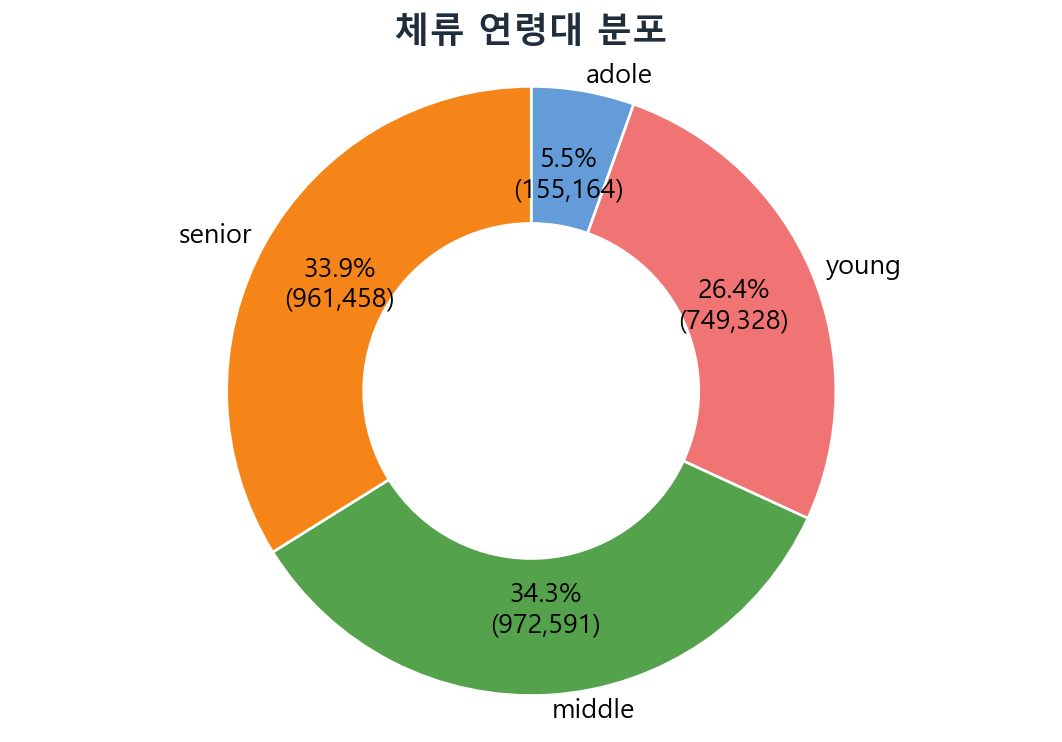

In [382]:
set_ppt_style(base_size=12)
fig1, _ = plot_age_pie(stay_agg, hdong_cd = 4713035000)
plt.show()

### 나이 x 체류 목적 별

In [383]:
def plot_age_purpose_stacked(
    stay_agg,
    ages=("adole","young","middle","senior"),
    purpose_list=None,
    age_order=("adole","young","middle","senior"),
    title=None,
    figsize=(9.2, 5.0),
    min_ratio_label=0.07,
    hdong_cd=None
):
    _ensure_cols(stay_agg)

    df = _filter_hdong(stay_agg, hdong_cd)
    df = df[df["age_grp"].isin(ages)].copy()
    if purpose_list is not None:
        df = df[df["purpose_grp"].isin(purpose_list)].copy()
    if df.empty:
        raise ValueError("조건에 맞는 데이터가 없습니다.")

    pv = (df.groupby(["age_grp","purpose_grp"])["stay_cnts_sum"]
            .sum().unstack(fill_value=0.0))
    pv = pv.reindex(age_order).dropna(how="all")

    default_order = ["귀가","업무","학업","쇼핑여가","여행","기타"]
    col_order = [c for c in default_order if c in pv.columns] + \
                [c for c in pv.columns if c not in default_order]
    pv = pv[col_order]

    totals = pv.sum(axis=1).replace(0, np.nan)

    if title is None:
        title = "연령대 × 체류목적 : 체류인구수 & 목적 비율"

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontweight="bold", color=THEME["text"])

    x = np.arange(len(pv.index))
    bottom = np.zeros(len(pv.index))

    for col in pv.columns:
        vals = pv[col].to_numpy()
        color = THEME["purpose_colors"].get(col, "#9DAAB6")

        bars = ax.bar(x, vals, bottom=bottom, color=color, width=0.62,
                      edgecolor="white", linewidth=0.9, label=col)

        ratios = vals / totals.to_numpy()
        for i, (b, r, v) in enumerate(zip(bars, ratios, vals)):
            if np.isnan(r) or v <= 0 or r < min_ratio_label:
                continue
            ax.text(b.get_x()+b.get_width()/2, bottom[i] + v/2,
                    f"{r*100:.0f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold", color="white")

        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(a) for a in pv.index])
    ax.set_xlabel("나이")
    ax.set_ylabel("체류인구수")
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
    _clean_axes(ax)

    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    return fig, ax

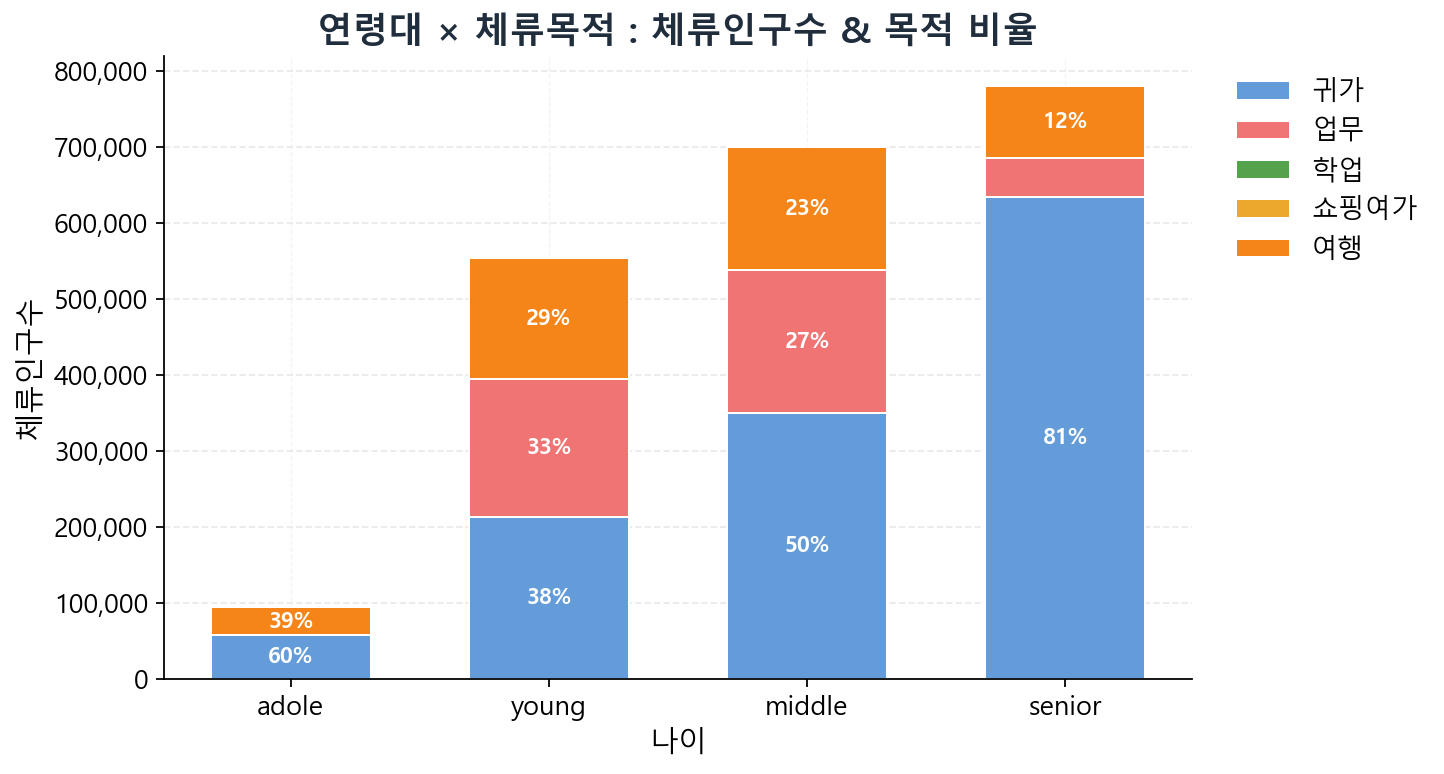

In [384]:
set_ppt_style(base_size=12)
fig2, _ = plot_age_purpose_stacked(
    stay_agg,
    ages=("adole", "young", "middle","senior"),
    purpose_list=["귀가","여행", "업무", "학업", "쇼핑여가"],
    hdong_cd=4713035000
)
plt.show()

### 시간 x 나이대 선 그래프: 피크 시간대

In [385]:
def plot_time_by_age_lines(
    stay_agg,
    ages=("adole","young","middle","senior"),
    title="시간대별 체류인구 추이(연령대별)",
    figsize_unit=(5.6, 4.2),
    y_zoom="per_age",
    y_pad_ratio=0.10,
    fill_alpha=0.18,
    hdong_cd=None
):
    _ensure_cols(stay_agg)

    df0 = _filter_hdong(stay_agg, hdong_cd)

    ages = list(ages)
    if len(ages) == 0:
        raise ValueError("ages는 최소 1개 이상.")
    if len(ages) > 4:
        raise ValueError("연령대는 최대 4개까지.")

    if len(ages) == 1:
        nrows, ncols = 1, 1
    elif len(ages) == 2:
        nrows, ncols = 1, 2
    elif len(ages) == 3:
        nrows, ncols = 1, 3
    else:
        nrows, ncols = 2, 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows),
        squeeze=False
    )
    fig.suptitle(title, y=1.03, fontsize=15, fontweight="bold", color=THEME["text"])

    df = (df0[df0["age_grp"].isin(ages)]
          .groupby(["age_grp","time_bin"])["stay_cnts_sum"]
          .sum().reset_index())
    df["time_bin"] = df["time_bin"].astype(int)

    global_ylim = None
    if y_zoom == "global" and not df.empty:
        gmin, gmax = df["stay_cnts_sum"].min(), df["stay_cnts_sum"].max()
        pad = (gmax - gmin) * y_pad_ratio if gmax > gmin else max(gmin*0.01, 1.0)
        global_ylim = (gmin - pad, gmax + pad)

    axes_flat = axes.flatten()

    for k, age in enumerate(ages):
        ax = axes_flat[k]
        sub = df[df["age_grp"] == age].sort_values("time_bin")
        if sub.empty:
            ax.axis("off")
            continue

        x = sub["time_bin"].to_numpy()
        y = sub["stay_cnts_sum"].to_numpy()
        c = THEME["line_colors"].get(age, "#4C78A8")

        ax.plot(x, y, color=c, linewidth=2.6, marker="o", markersize=4.6)
        ax.fill_between(x, y, 0, color=c, alpha=fill_alpha)

        idx = int(np.argmax(y))
        x_peak, y_peak = int(x[idx]), float(y[idx])
        ax.axvline(x_peak, color=THEME["peak"], linewidth=1.0, alpha=0.55)
        ax.axhline(y_peak, color=THEME["peak"], linewidth=1.0, alpha=0.30)
        ax.scatter([x_peak], [y_peak], s=60, color=c,
                   edgecolor="white", linewidth=1.0, zorder=5)
        ax.text(x_peak + 0.15, y_peak,
                f"peak {_time_label(x_peak)}\n{y_peak:,.0f}",
                fontsize=10, fontweight="bold",
                color=THEME["text"], va="center")

        if y_zoom == "per_age":
            ymin, ymax = y.min(), y.max()
            pad = (ymax - ymin) * y_pad_ratio if ymax > ymin else max(ymin*0.01, 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
        elif y_zoom == "global" and global_ylim is not None:
            ax.set_ylim(*global_ylim)

        ax.set_title(age, fontweight="bold", color=THEME["text"])
        ax.set_xlabel("시간")
        ax.set_ylabel("체류인구수")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        ax.set_xticks(sorted(np.unique(x)))
        ax.set_xticklabels([_time_label(t) for t in sorted(np.unique(x))],
                           rotation=45, ha="right")
        _clean_axes(ax)

    for j in range(len(ages), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes

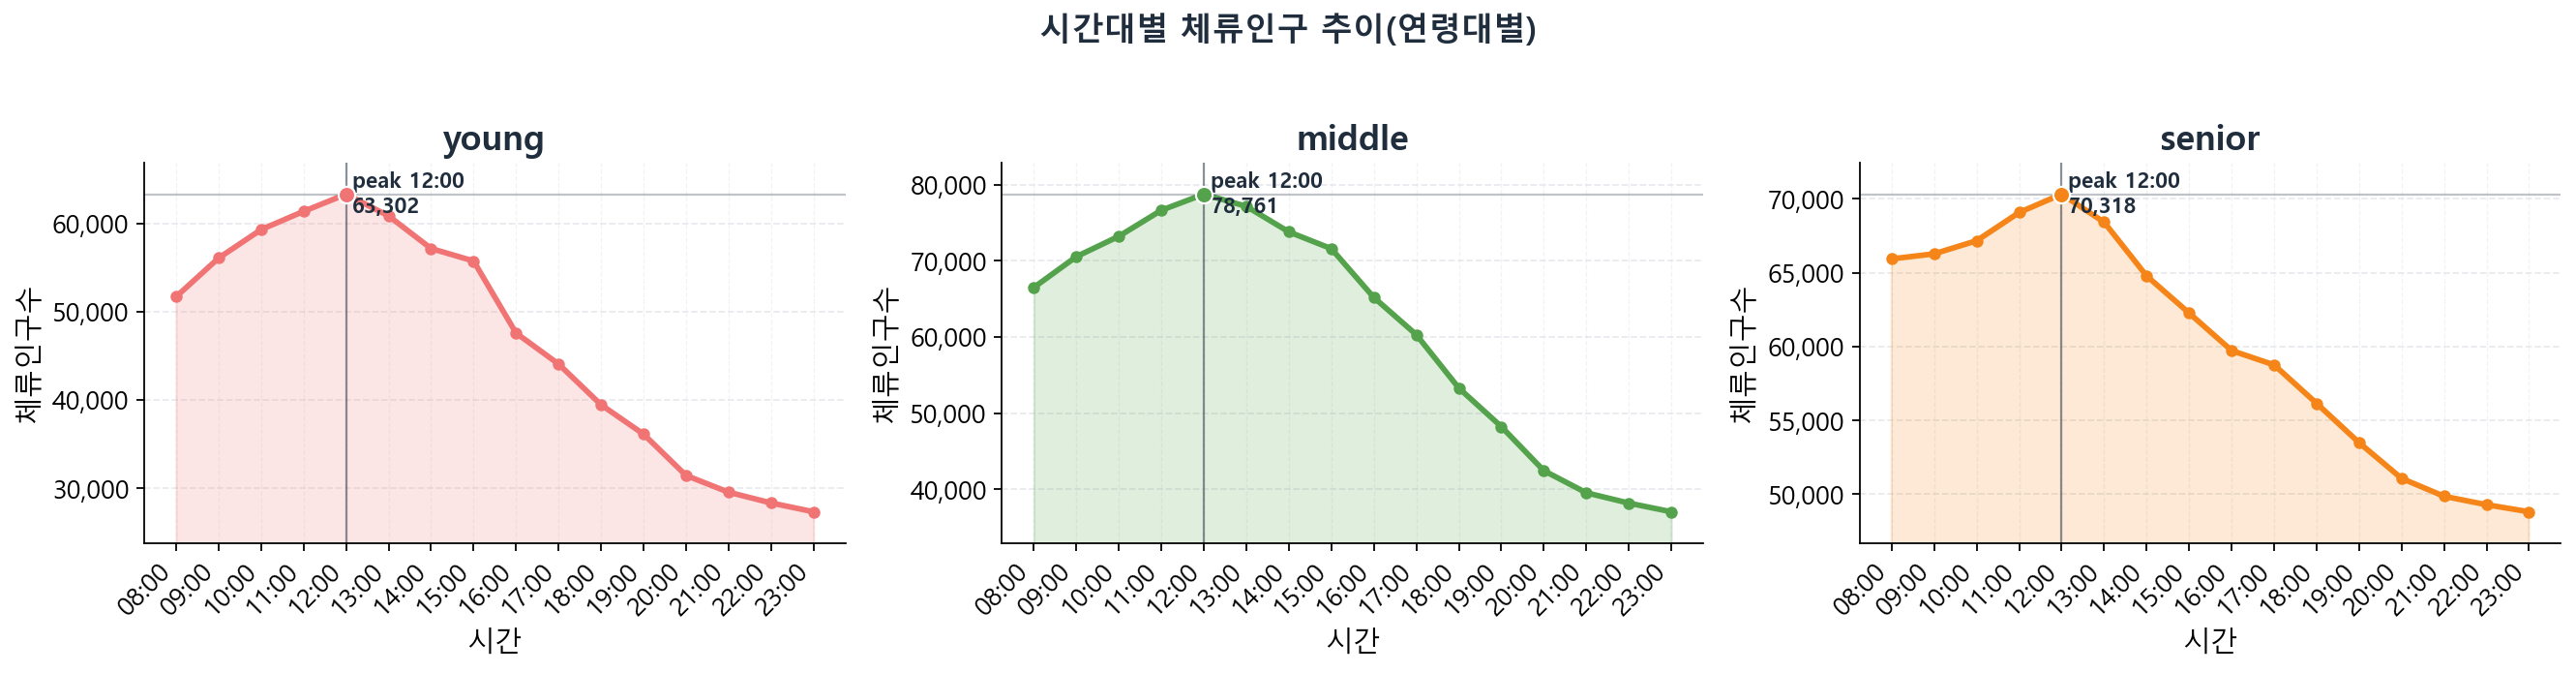

In [386]:
set_ppt_style(base_size=12)
fig3, _ = plot_time_by_age_lines(
    stay_agg, 
    title="시간대별 체류인구 추이(연령대별)",
    ages=("young","middle","senior"),
    hdong_cd=4713035000, y_zoom="per_age")
plt.show()

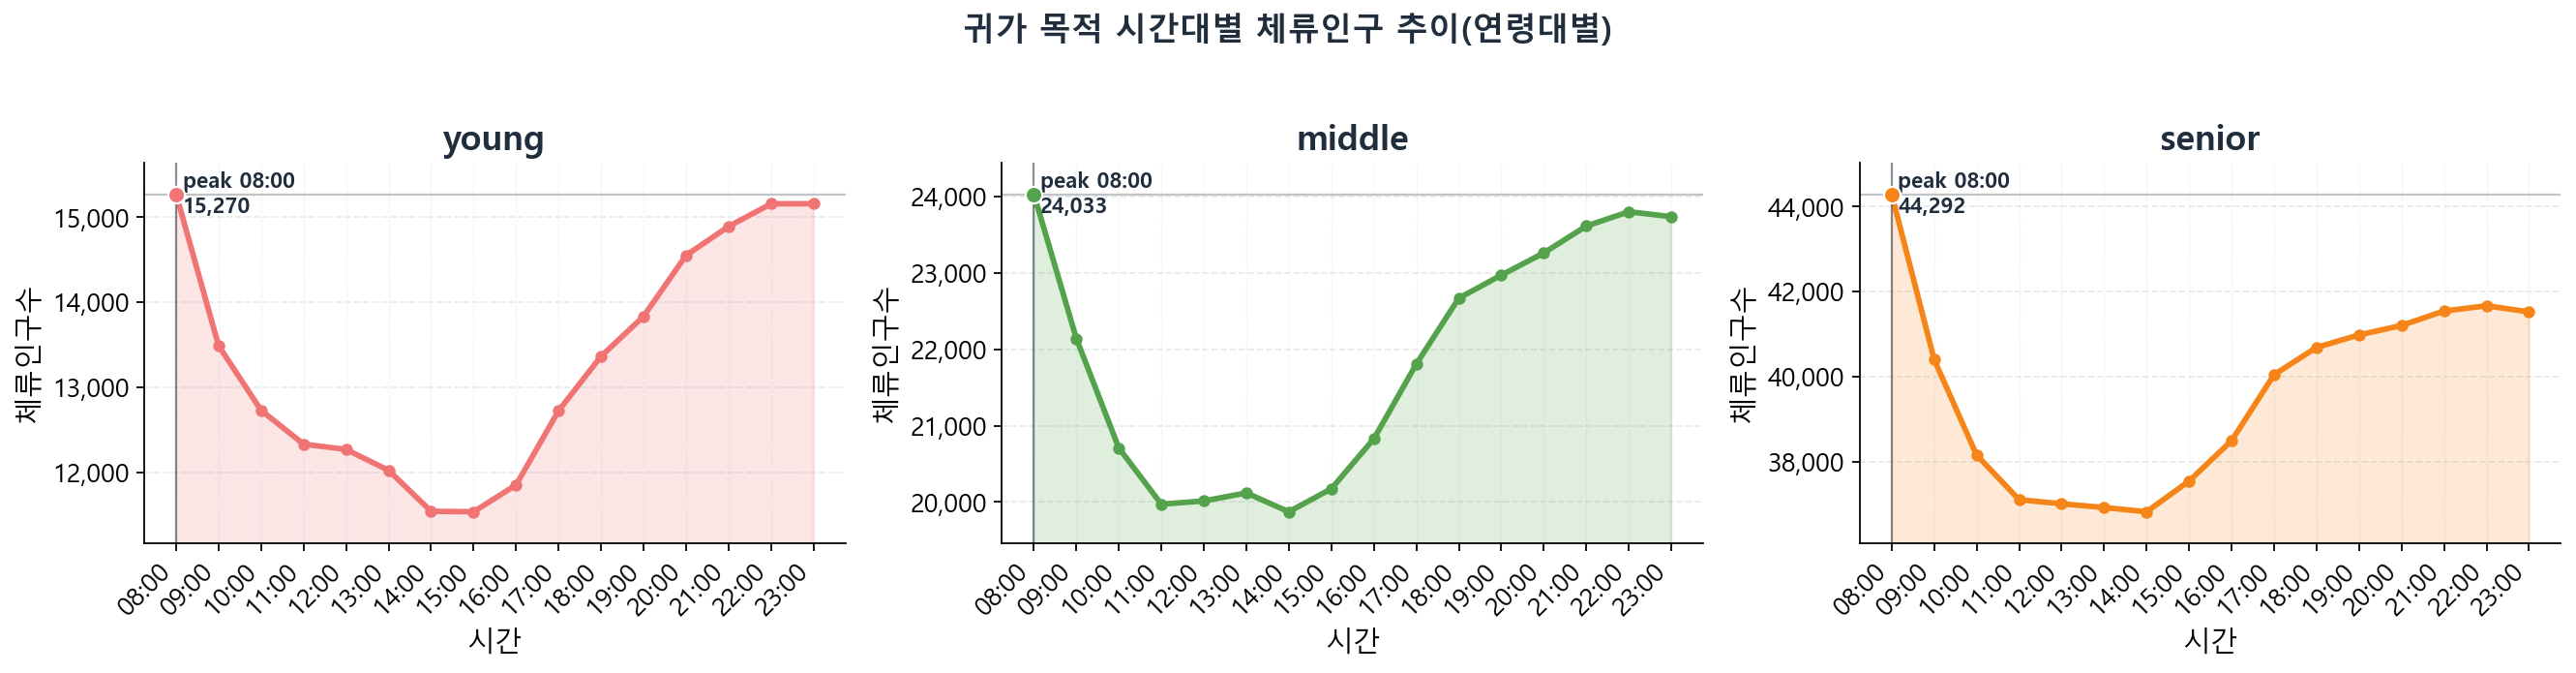

In [387]:
set_ppt_style(base_size=12)
fig3, _ = plot_time_by_age_lines(
    stay_agg[stay_agg['purpose_grp'] == '귀가'], 
    title="귀가 목적 시간대별 체류인구 추이(연령대별)",
    ages=("young","middle","senior"),
    hdong_cd=4713035000, y_zoom="per_age")
plt.show()

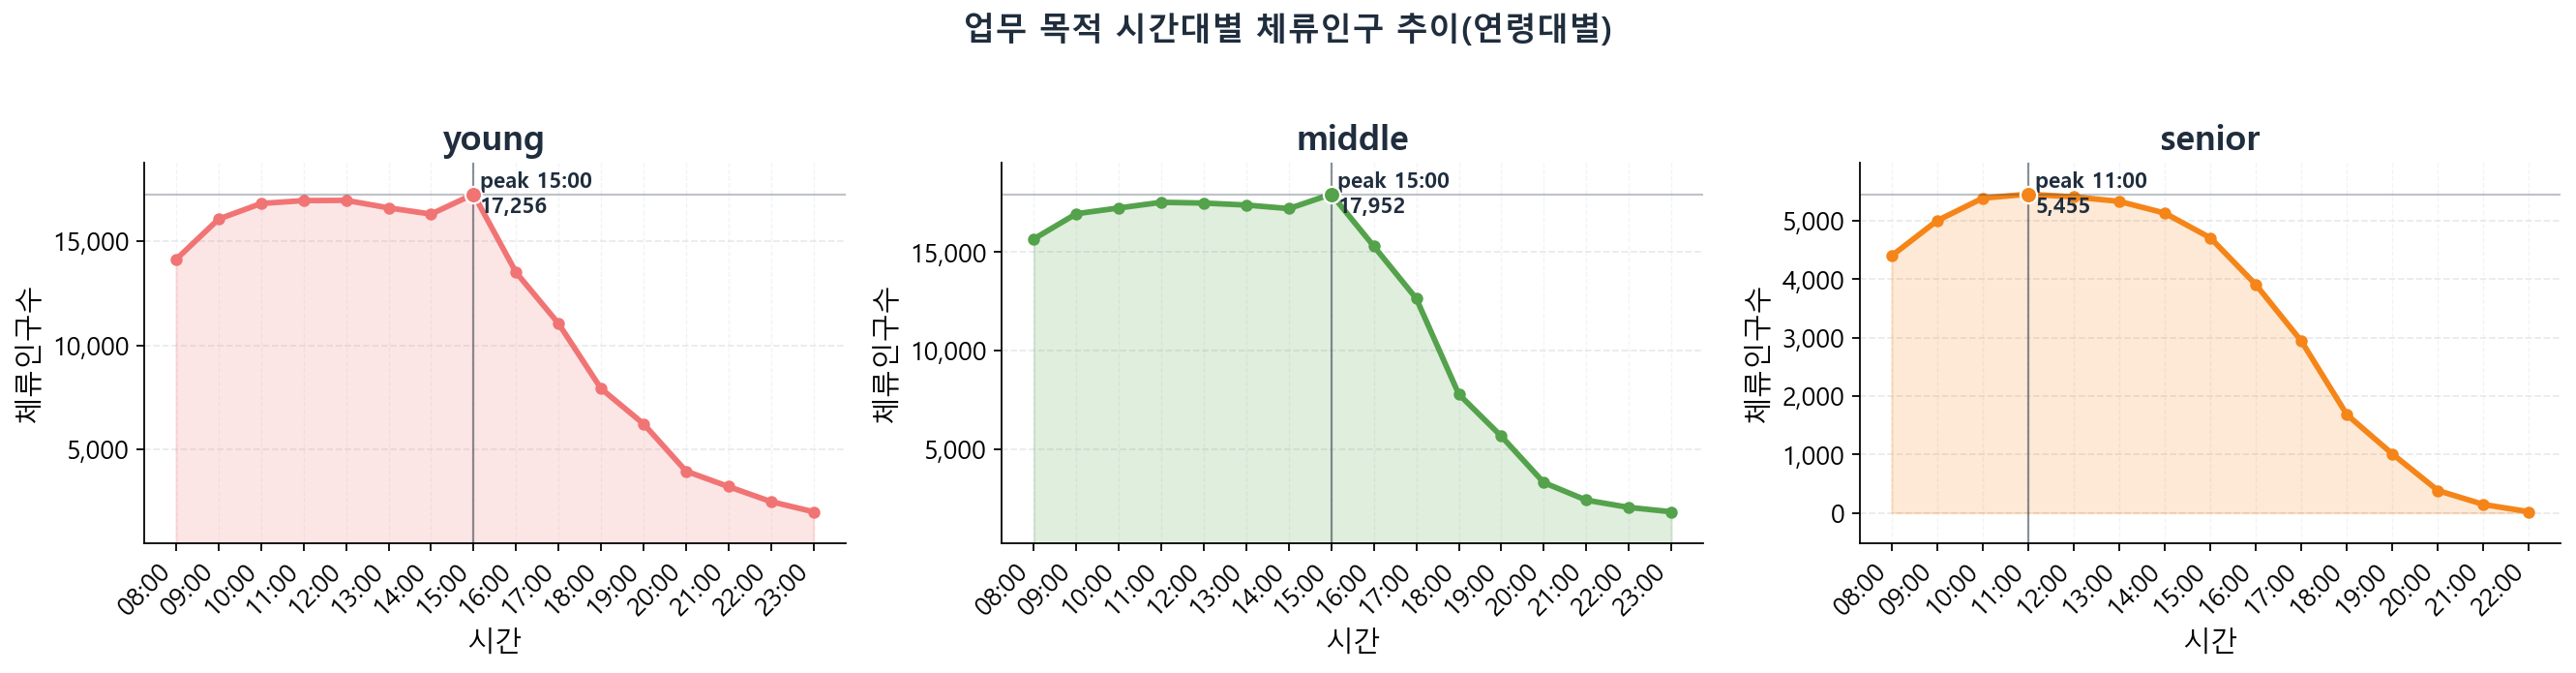

In [388]:
set_ppt_style(base_size=12)
fig3, _ = plot_time_by_age_lines(
    stay_agg[stay_agg['purpose_grp'] == '업무'], 
    title="업무 목적 시간대별 체류인구 추이(연령대별)",
    ages=("young","middle","senior"),
    hdong_cd=4713035000, y_zoom="per_age")
plt.show()

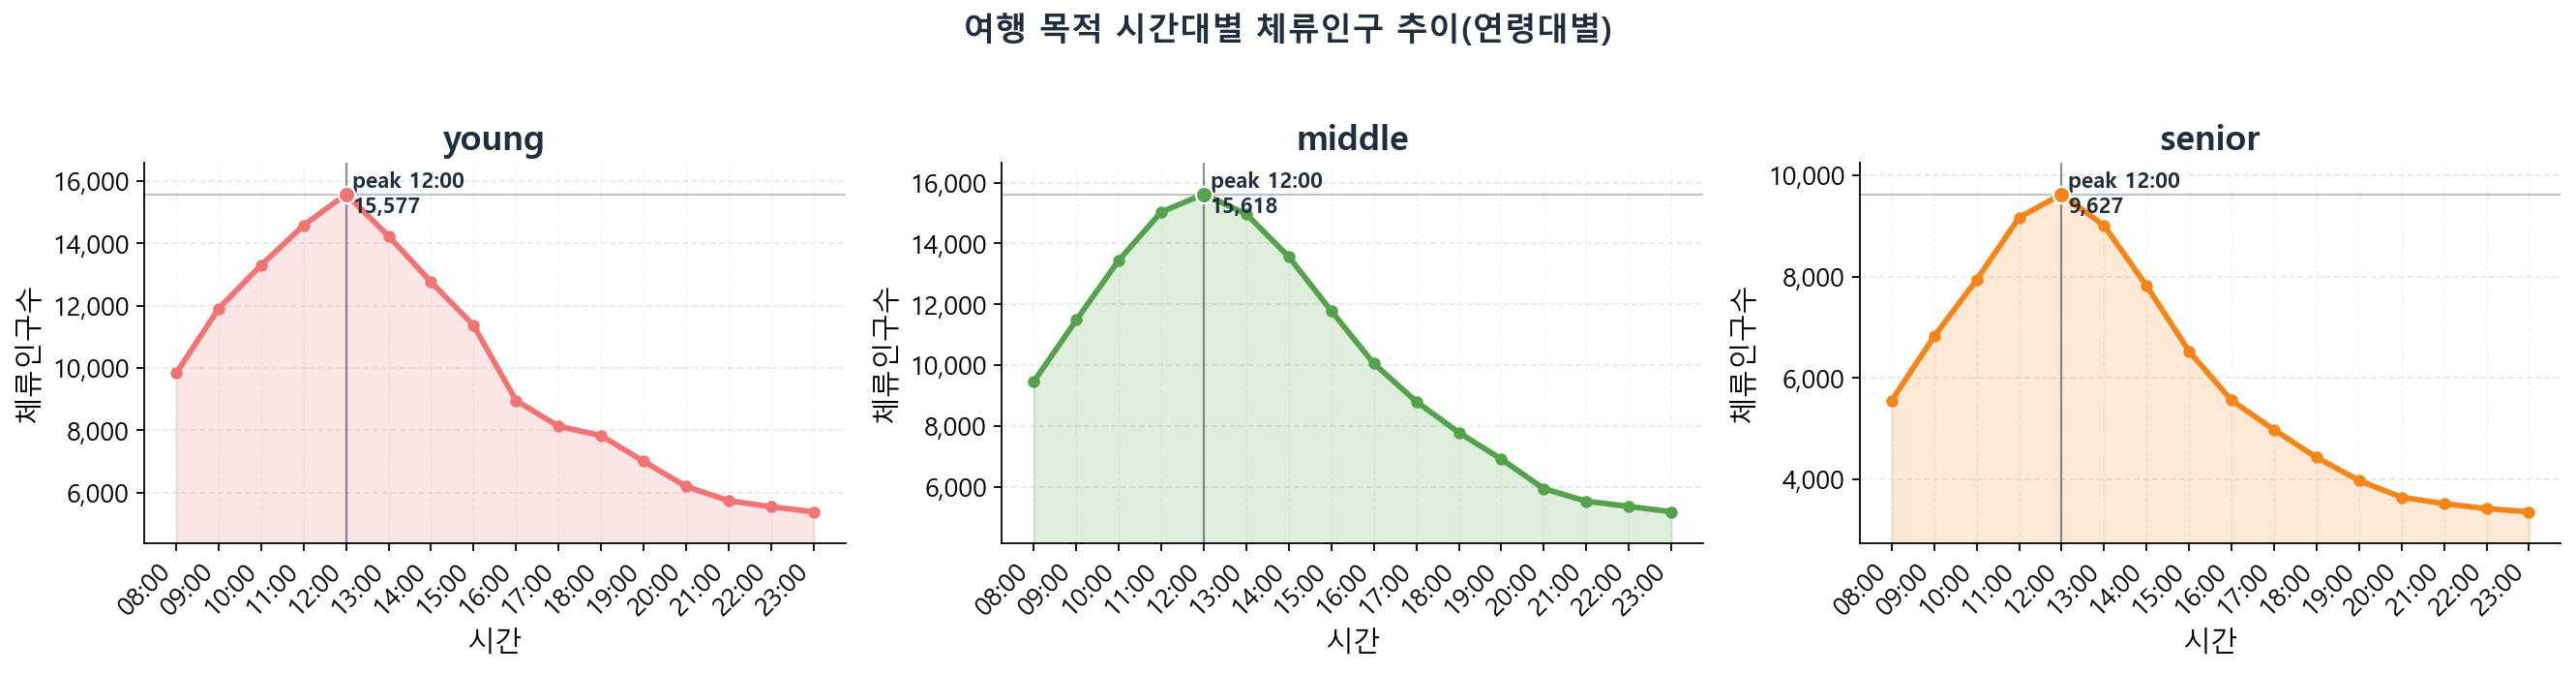

In [389]:
set_ppt_style(base_size=12)
fig3, _ = plot_time_by_age_lines(
    stay_agg[stay_agg['purpose_grp'] == '여행'], 
    title="여행 목적 시간대별 체류인구 추이(연령대별)",
    ages=("young","middle","senior"),
    hdong_cd=4713035000, y_zoom="per_age")
plt.show()

### 시간 x 체류 목적 별: 선 그래프

In [390]:
def plot_stay_time_by_purpose_lines(
    stay_agg,
    hdong_cd=4713035000,
    purpose_list=None,  # None이면 전체 목적
    title="시간대별 체류(목적별)",
    figsize_unit=(5.8, 4.2),
    fill_alpha=0.12,
    y_zoom="per_purpose",   # "per_purpose" / "global" / None
    y_pad_ratio=0.10
):
    _ensure_cols(stay_agg)
    df0 = _filter_hdong(stay_agg, hdong_cd)

    if purpose_list is None:
        purposes = df0["purpose_grp"].dropna().unique().tolist()
    else:
        purposes = list(purpose_list)

    # 보기 좋은 목적 순서(존재하는 것만)
    default_order = ["귀가","업무","학업","쇼핑여가","여행","기타"]
    purposes = [p for p in default_order if p in purposes] + [p for p in purposes if p not in default_order]
    n = len(purposes)
    if n == 0:
        raise ValueError("purpose_list 조건에서 목적이 0개입니다.")

    # 집계
    df = (df0[df0["purpose_grp"].isin(purposes)]
          .groupby(["purpose_grp","time_bin"], as_index=False)["stay_cnts_sum"]
          .sum())
    df["time_bin"] = df["time_bin"].astype(int)
    if df.empty:
        raise ValueError("조건에 맞는 데이터가 없습니다.")

    # 레이아웃
    nrows, ncols = _subplot_grid_purpose(n)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows), squeeze=False)
    fig.suptitle(title, y=1.03, fontsize=15, fontweight="bold", color=THEME["text"])
    axes_flat = axes.flatten()

    # global y축
    global_ylim = None
    if y_zoom == "global":
        gmin, gmax = float(df["stay_cnts_sum"].min()), float(df["stay_cnts_sum"].max())
        pad = (gmax - gmin) * y_pad_ratio if gmax > gmin else max(gmin*0.01, 1.0)
        global_ylim = (gmin - pad, gmax + pad)

    for i, p in enumerate(purposes):
        ax = axes_flat[i]
        sub = df[df["purpose_grp"] == p].sort_values("time_bin")
        if sub.empty:
            ax.axis("off")
            continue

        x = sub["time_bin"].to_numpy()
        y = sub["stay_cnts_sum"].to_numpy()
        c = THEME["purpose_colors"].get(p, "#9DAAB6")

        ax.plot(x, y, color=c, linewidth=2.6, marker="o", markersize=4.6)
        ax.fill_between(x, y, 0, color=c, alpha=fill_alpha)

        # y축 줌
        if y_zoom == "per_purpose":
            ymin, ymax = float(y.min()), float(y.max())
            pad = (ymax - ymin) * y_pad_ratio if ymax > ymin else max(ymin*0.01, 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
        elif y_zoom == "global" and global_ylim is not None:
            ax.set_ylim(*global_ylim)

        ax.set_title(f"purpose = {p}", fontweight="bold", color=THEME["text"])
        xticks = sorted(np.unique(x))
        ax.set_xticks(xticks)
        ax.set_xticklabels([_time_label(t) for t in xticks], rotation=45, ha="right")
        ax.set_xlabel("time_bin")
        ax.set_ylabel("stay_cnts_sum")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        _clean_axes(ax)
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))


    # 남는 축 끄기
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes

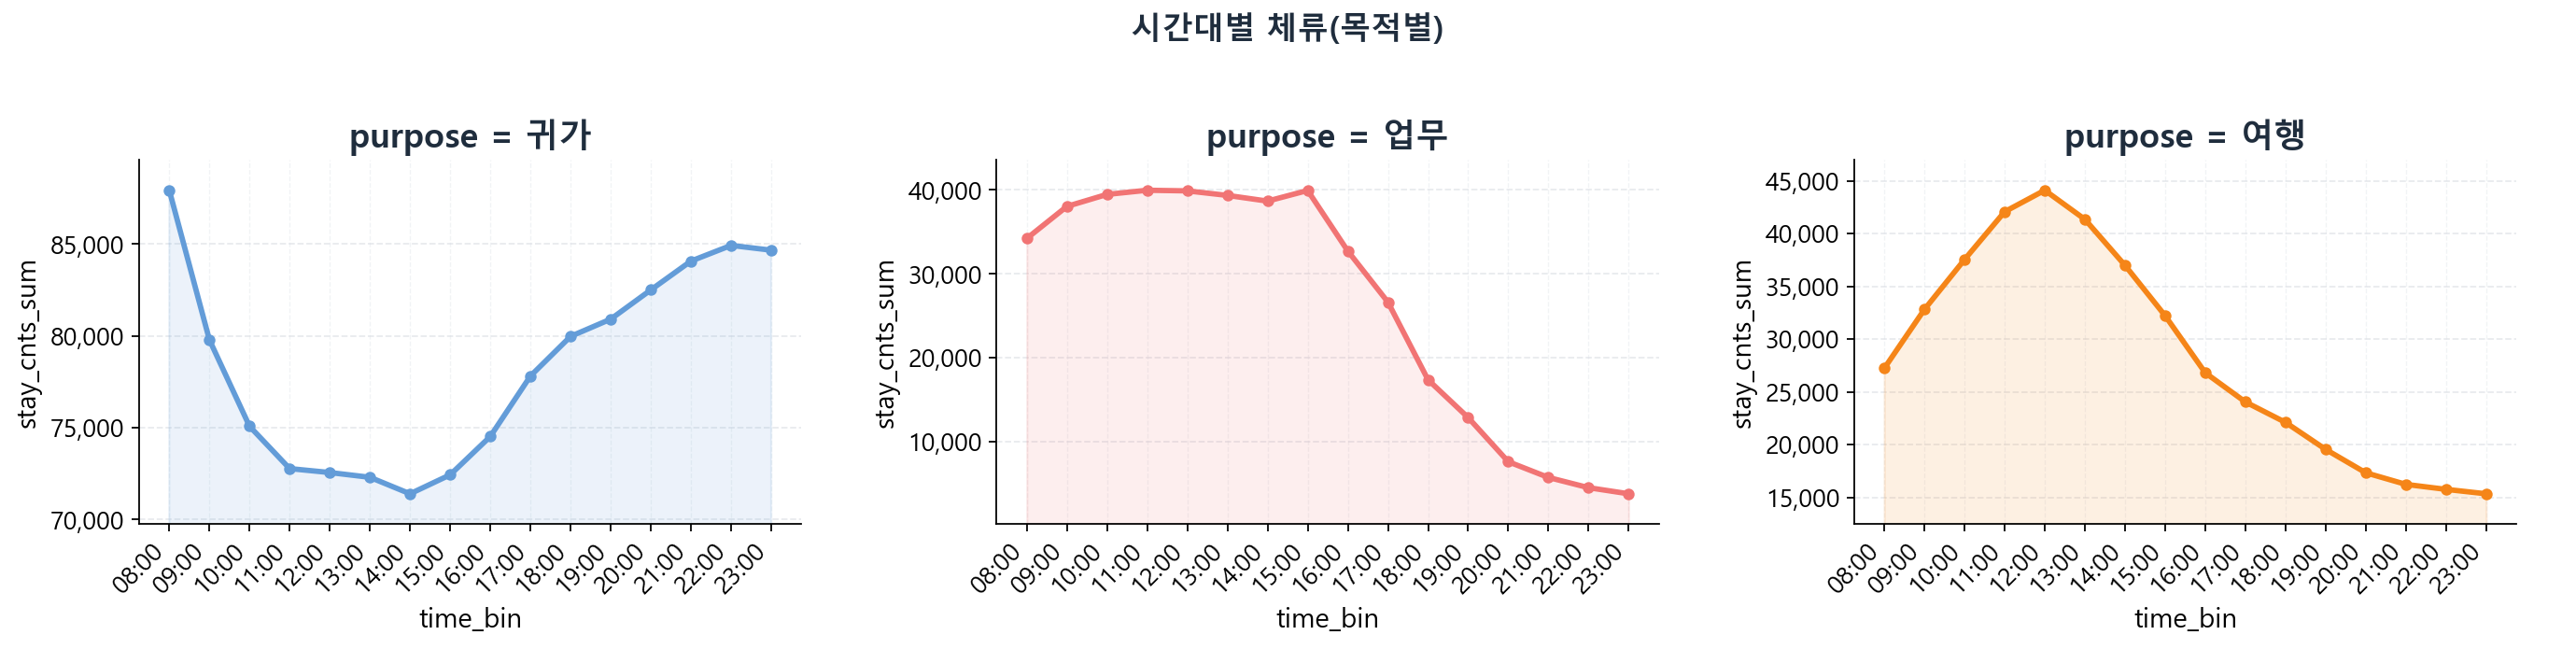

In [400]:
set_ppt_style(base_size=12)
fig1, _ = plot_stay_time_by_purpose_lines(
    stay_agg,
    hdong_cd=4713035000,
    purpose_list=['귀가', '업무', '여행'],         # 전체 목적
    y_zoom="per_purpose"
)
plt.show()
plt.show()


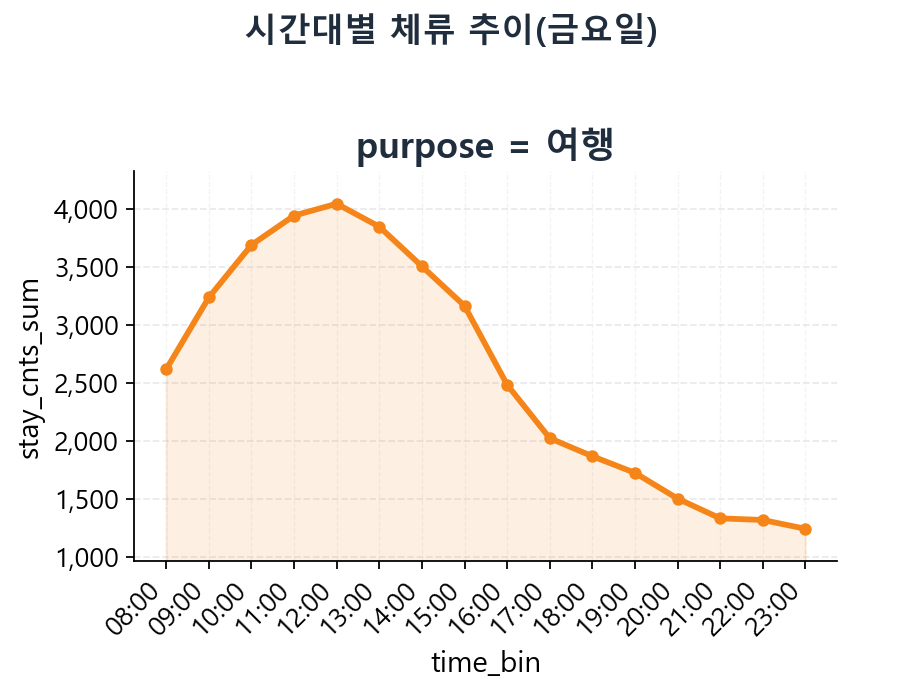

In [392]:
set_ppt_style(base_size=12)
fig1, _ = plot_stay_time_by_purpose_lines(
    stay_agg[(stay_agg['weekday'] == 'Fri')& (stay_agg['age_grp'] == 'young')],
    title="시간대별 체류 추이(금요일)",
    hdong_cd=4713035000,
    purpose_list=['여행'],         # 전체 목적
    y_zoom="per_purpose"
)
plt.show()
plt.show()


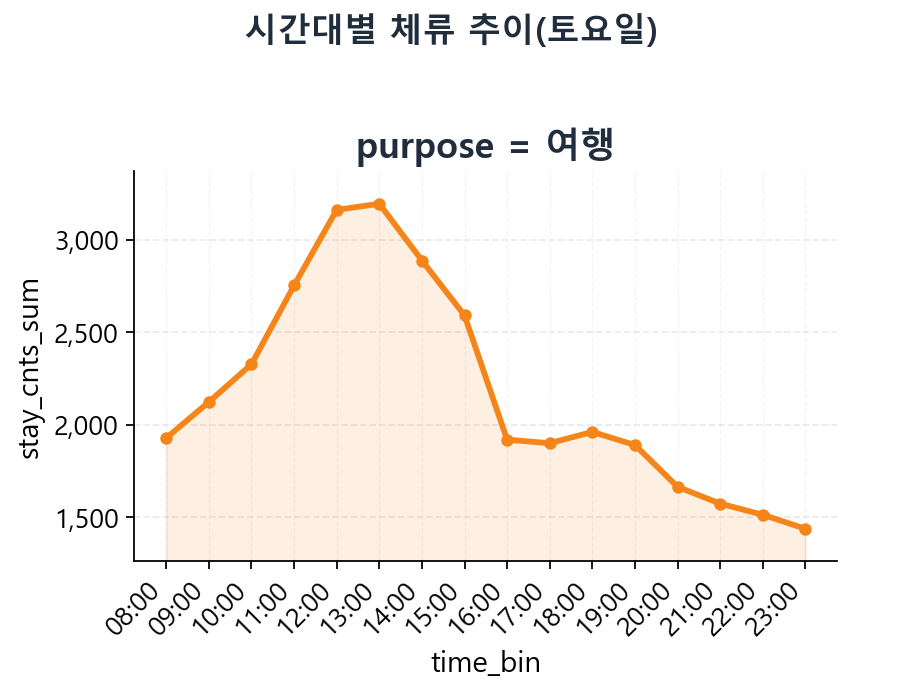

In [393]:
set_ppt_style(base_size=12)
fig1, _ = plot_stay_time_by_purpose_lines(
    stay_agg[(stay_agg['weekday'] == 'Sat')& (stay_agg['age_grp'] == 'young')],
    title="시간대별 체류 추이(토요일)",
    hdong_cd=4713035000,
    purpose_list=['여행'],         # 전체 목적
    y_zoom="per_purpose"
)
plt.show()
plt.show()


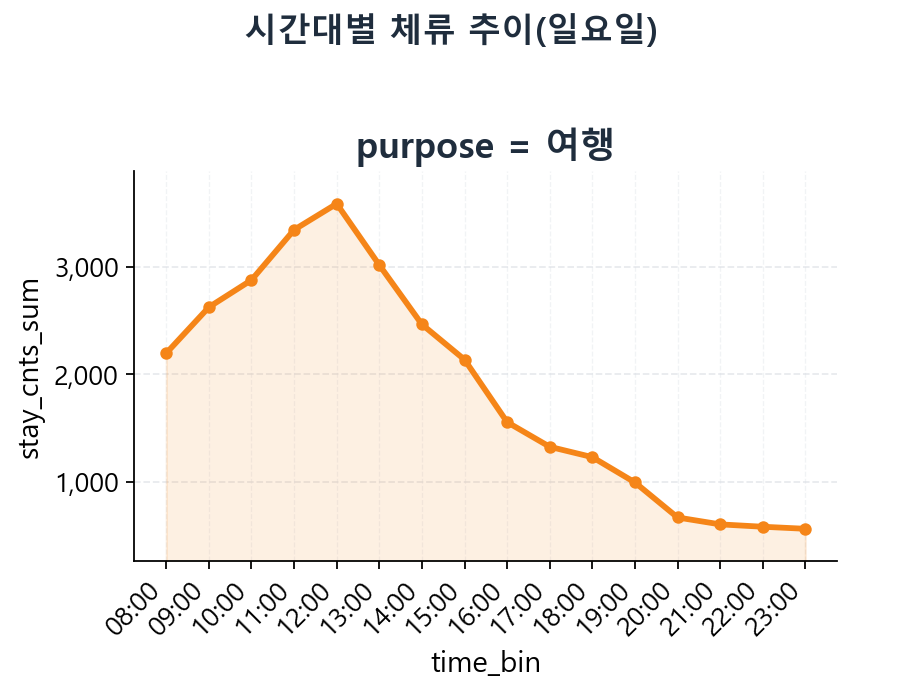

In [394]:
set_ppt_style(base_size=12)
fig1, _ = plot_stay_time_by_purpose_lines(
    stay_agg[(stay_agg['weekday'] == 'Sun')& (stay_agg['age_grp'] == 'young')],
    title="시간대별 체류 추이(일요일)",
    hdong_cd=4713035000,
    purpose_list=['여행'],         # 전체 목적
    y_zoom="per_purpose"
)
plt.show()
plt.show()


### 요일 x 체류 목적 별: 막대 그래프

In [395]:
def plot_stay_weekday_by_purpose_bars(
    stay_agg,
    hdong_cd=4713035000,
    purpose_list=None,  # 예: ["귀가","여행"]
    title="요일별 체류(목적별)",
    figsize_unit=(5.6, 4.0)
):
    _ensure_cols(stay_agg)
    df0 = _filter_hdong(stay_agg, hdong_cd)

    if purpose_list is None:
        purposes = df0["purpose_grp"].dropna().unique().tolist()
    else:
        purposes = list(purpose_list)

    default_order = ["귀가","업무","학업","쇼핑여가","여행","기타"]
    purposes = [p for p in default_order if p in purposes] + [p for p in purposes if p not in default_order]
    n = len(purposes)
    if n == 0:
        raise ValueError("purpose_list 조건에서 목적이 0개입니다.")

    # 집계
    df = (df0[df0["purpose_grp"].isin(purposes)]
          .groupby(["purpose_grp","weekday"], as_index=False)["stay_cnts_sum"]
          .sum())
    if df.empty:
        raise ValueError("조건에 맞는 데이터가 없습니다.")

    nrows, ncols = _subplot_grid_purpose(n)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows), squeeze=False)
    fig.suptitle(title, y=1.03, fontsize=15, fontweight="bold", color=THEME["text"])
    axes_flat = axes.flatten()

    for i, p in enumerate(purposes):
        ax = axes_flat[i]
        sub = df[df["purpose_grp"] == p].copy()
        s = (sub.set_index("weekday")["stay_cnts_sum"]
                .reindex(WEEKDAY_ORDER))
        # NaN 제거 후 plotting
        s = s.dropna()
        if s.empty:
            ax.axis("off")
            continue

        xlabels = s.index.tolist()
        y = s.values
        x = np.arange(len(xlabels))
        c = THEME["purpose_colors"].get(p, "#9DAAB6")

        ax.bar(x, y, color=c, width=0.65, edgecolor="white", linewidth=0.9)
        ax.set_title(f"purpose = {p}", fontweight="bold", color=THEME["text"])
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel("weekday")
        ax.set_ylabel("stay_cnts_sum")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        _clean_axes(ax)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes

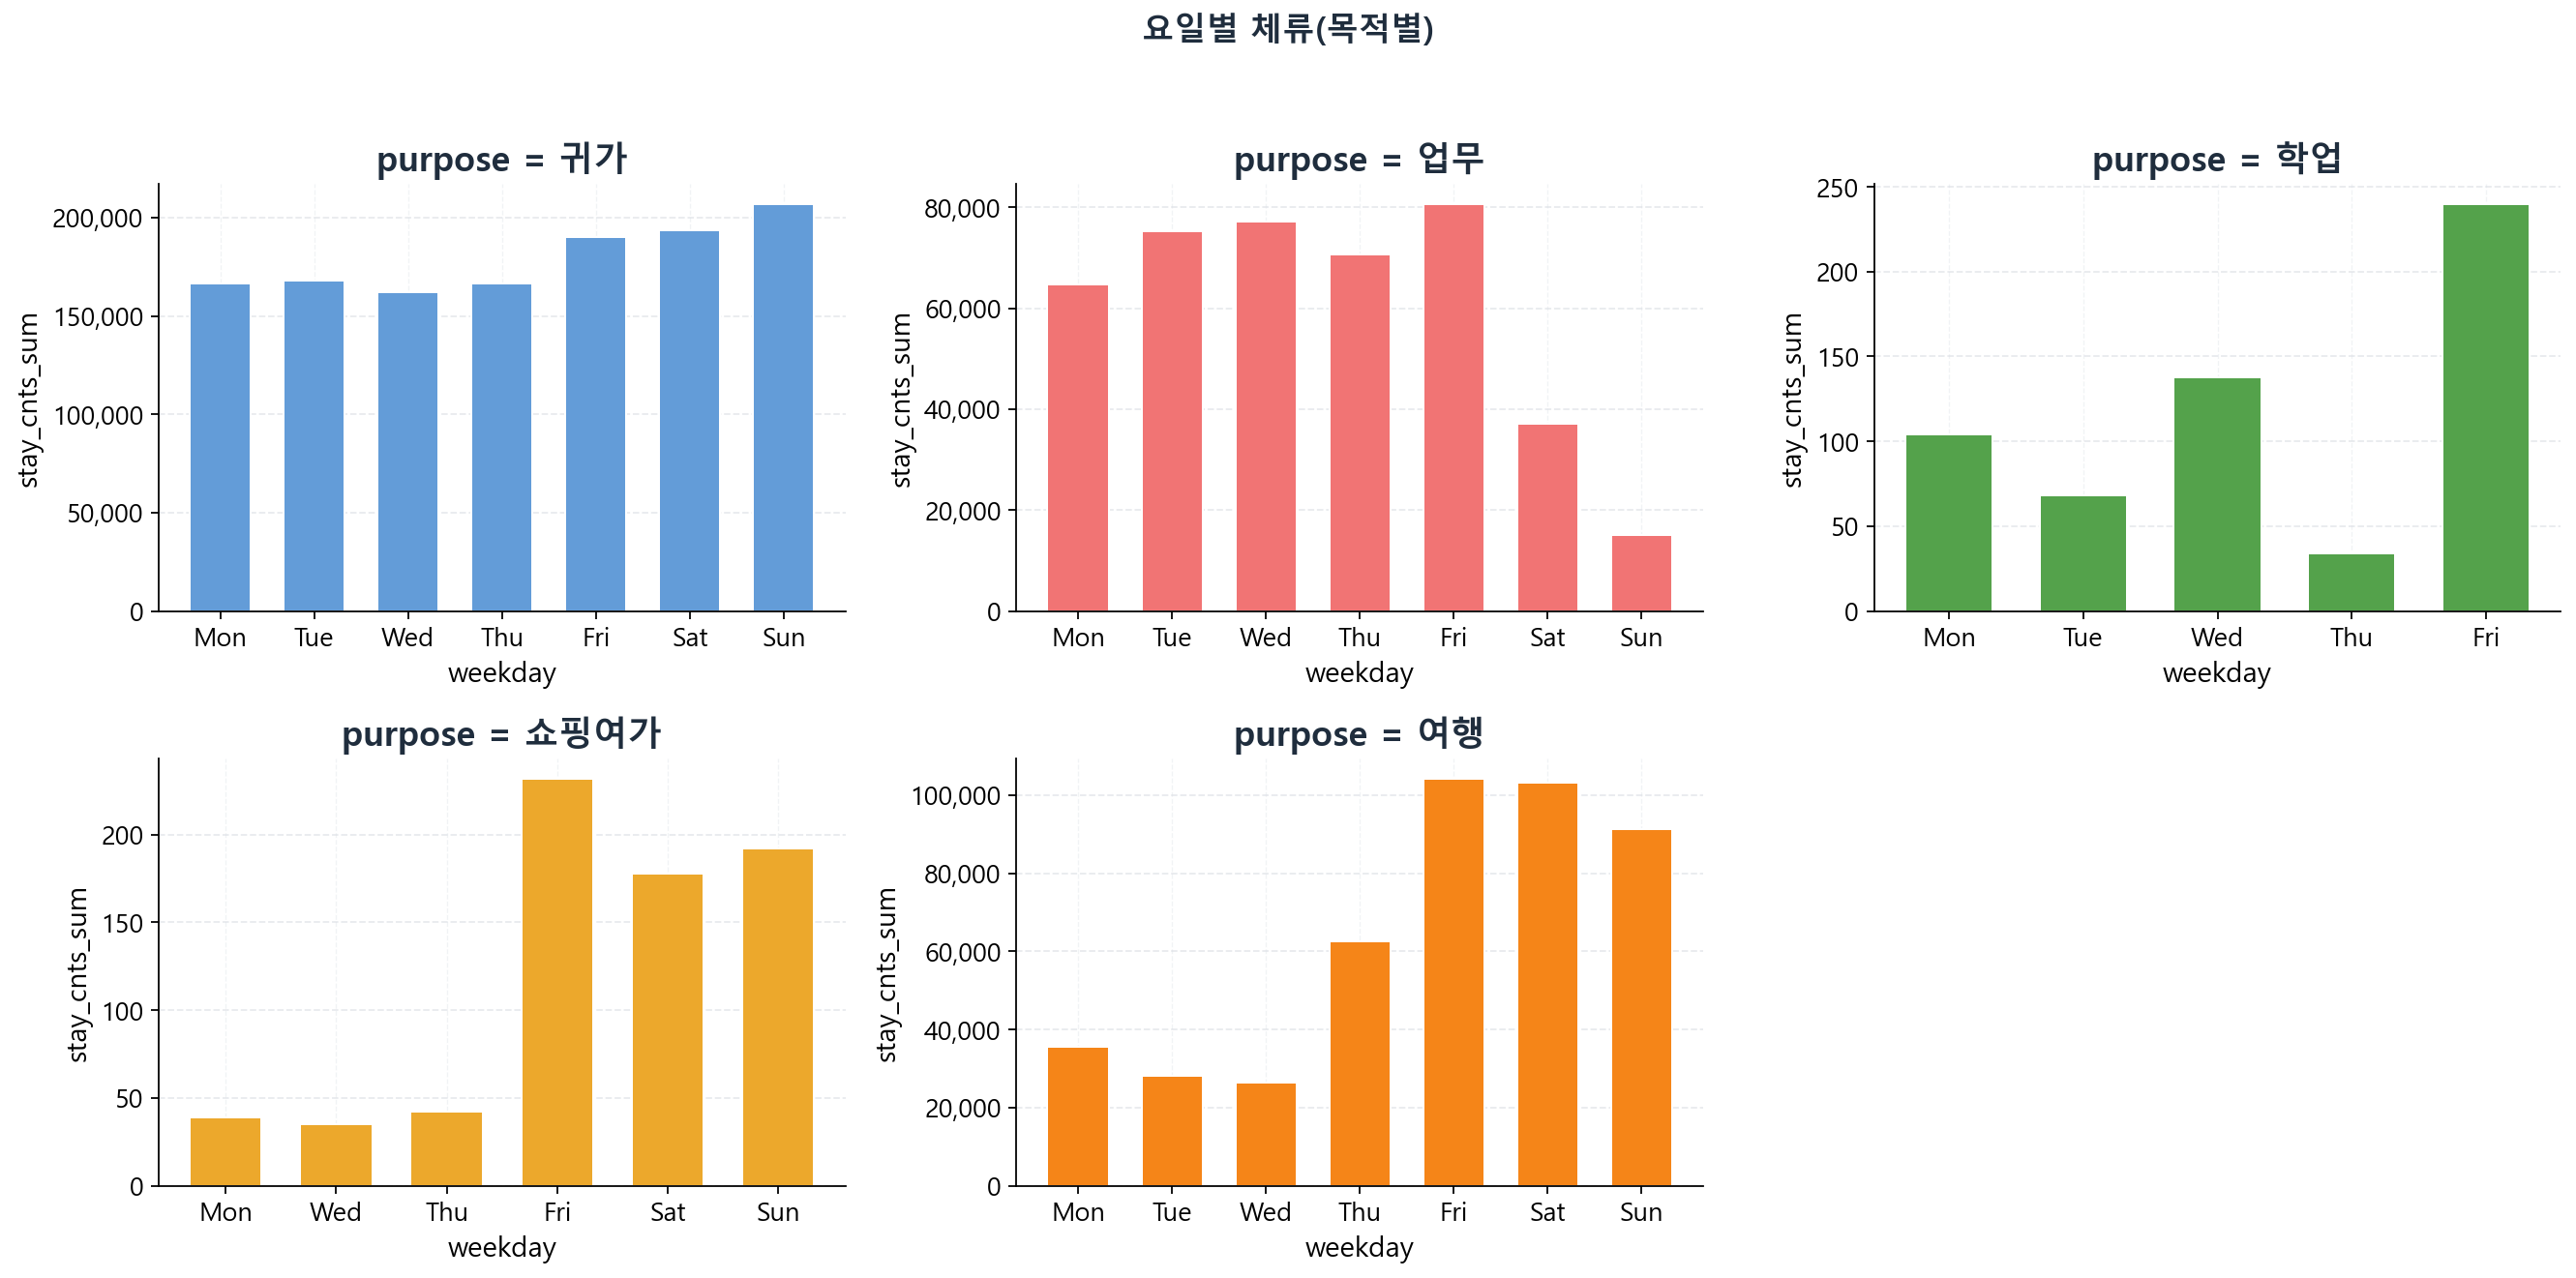

In [401]:
set_ppt_style(base_size=12)
fig2, _ = plot_stay_weekday_by_purpose_bars(
    stay_agg,
    hdong_cd=4713035000,
    purpose_list=["귀가","여행", "업무", "학업", "쇼핑여가"]  # 예시
)
plt.show()

### 요일 x 나이대: 막대 그래프

In [397]:
def plot_stay_weekday_by_age_bars(
    stay_agg,
    hdong_cd=4713035000,
    ages=("middle","senior"),  # 예: ("middle","senior")
    title="요일별 체류(나이대별)",
    figsize_unit=(5.6, 4.0),
    y_zoom="per_age",   # "per_age" / "global" / None
    y_pad_ratio=0.10
):
    _ensure_cols(stay_agg)
    df0 = _filter_hdong(stay_agg, hdong_cd)

    ages = list(ages)
    if len(ages) == 0:
        raise ValueError("ages는 최소 1개 이상이어야 합니다.")
    if len(ages) > 4:
        raise ValueError("age_grp은 최대 4개까지 지원합니다.")

    # 집계
    df = (
        df0[df0["age_grp"].isin(ages)]
        .groupby(["age_grp","weekday"], as_index=False)["stay_cnts_sum"]
        .sum()
    )
    if df.empty:
        raise ValueError("조건에 맞는 데이터가 없습니다.")

    nrows, ncols = _subplot_grid_age(len(ages))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_unit[0]*ncols, figsize_unit[1]*nrows),
        squeeze=False
    )
    fig.suptitle(title, y=1.03, fontsize=15, fontweight="bold", color=THEME["text"])
    axes_flat = axes.flatten()

    # global y축
    global_ylim = None
    if y_zoom == "global":
        gmin, gmax = float(df["stay_cnts_sum"].min()), float(df["stay_cnts_sum"].max())
        pad = (gmax - gmin) * y_pad_ratio if gmax > gmin else max(gmin*0.01, 1.0)
        global_ylim = (gmin - pad, gmax + pad)

    for i, age in enumerate(ages):
        ax = axes_flat[i]
        sub = df[df["age_grp"] == age].copy()

        s = (
            sub.set_index("weekday")["stay_cnts_sum"]
            .reindex(WEEKDAY_ORDER)
            .dropna()
        )
        if s.empty:
            ax.axis("off")
            continue

        xlabels = s.index.tolist()
        x = np.arange(len(xlabels))
        y = s.values
        c = THEME["age_colors"].get(age, "#4C78A8")

        # 막대그래프
        ax.bar(
            x, y,
            width=0.6,
            color=c,
            edgecolor="white",
            linewidth=0.9
        )

        # y축 줌
        if y_zoom == "per_age":
            ymin, ymax = float(y.min()), float(y.max())
            pad = (ymax - ymin) * y_pad_ratio if ymax > ymin else max(ymin*0.01, 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
        elif y_zoom == "global" and global_ylim is not None:
            ax.set_ylim(*global_ylim)

        ax.set_title(f"age = {age}", fontweight="bold", color=THEME["text"])
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel("weekday")
        ax.set_ylabel("stay_cnts_sum")
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_thousands))
        _clean_axes(ax)

    for j in range(len(ages), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    return fig, axes

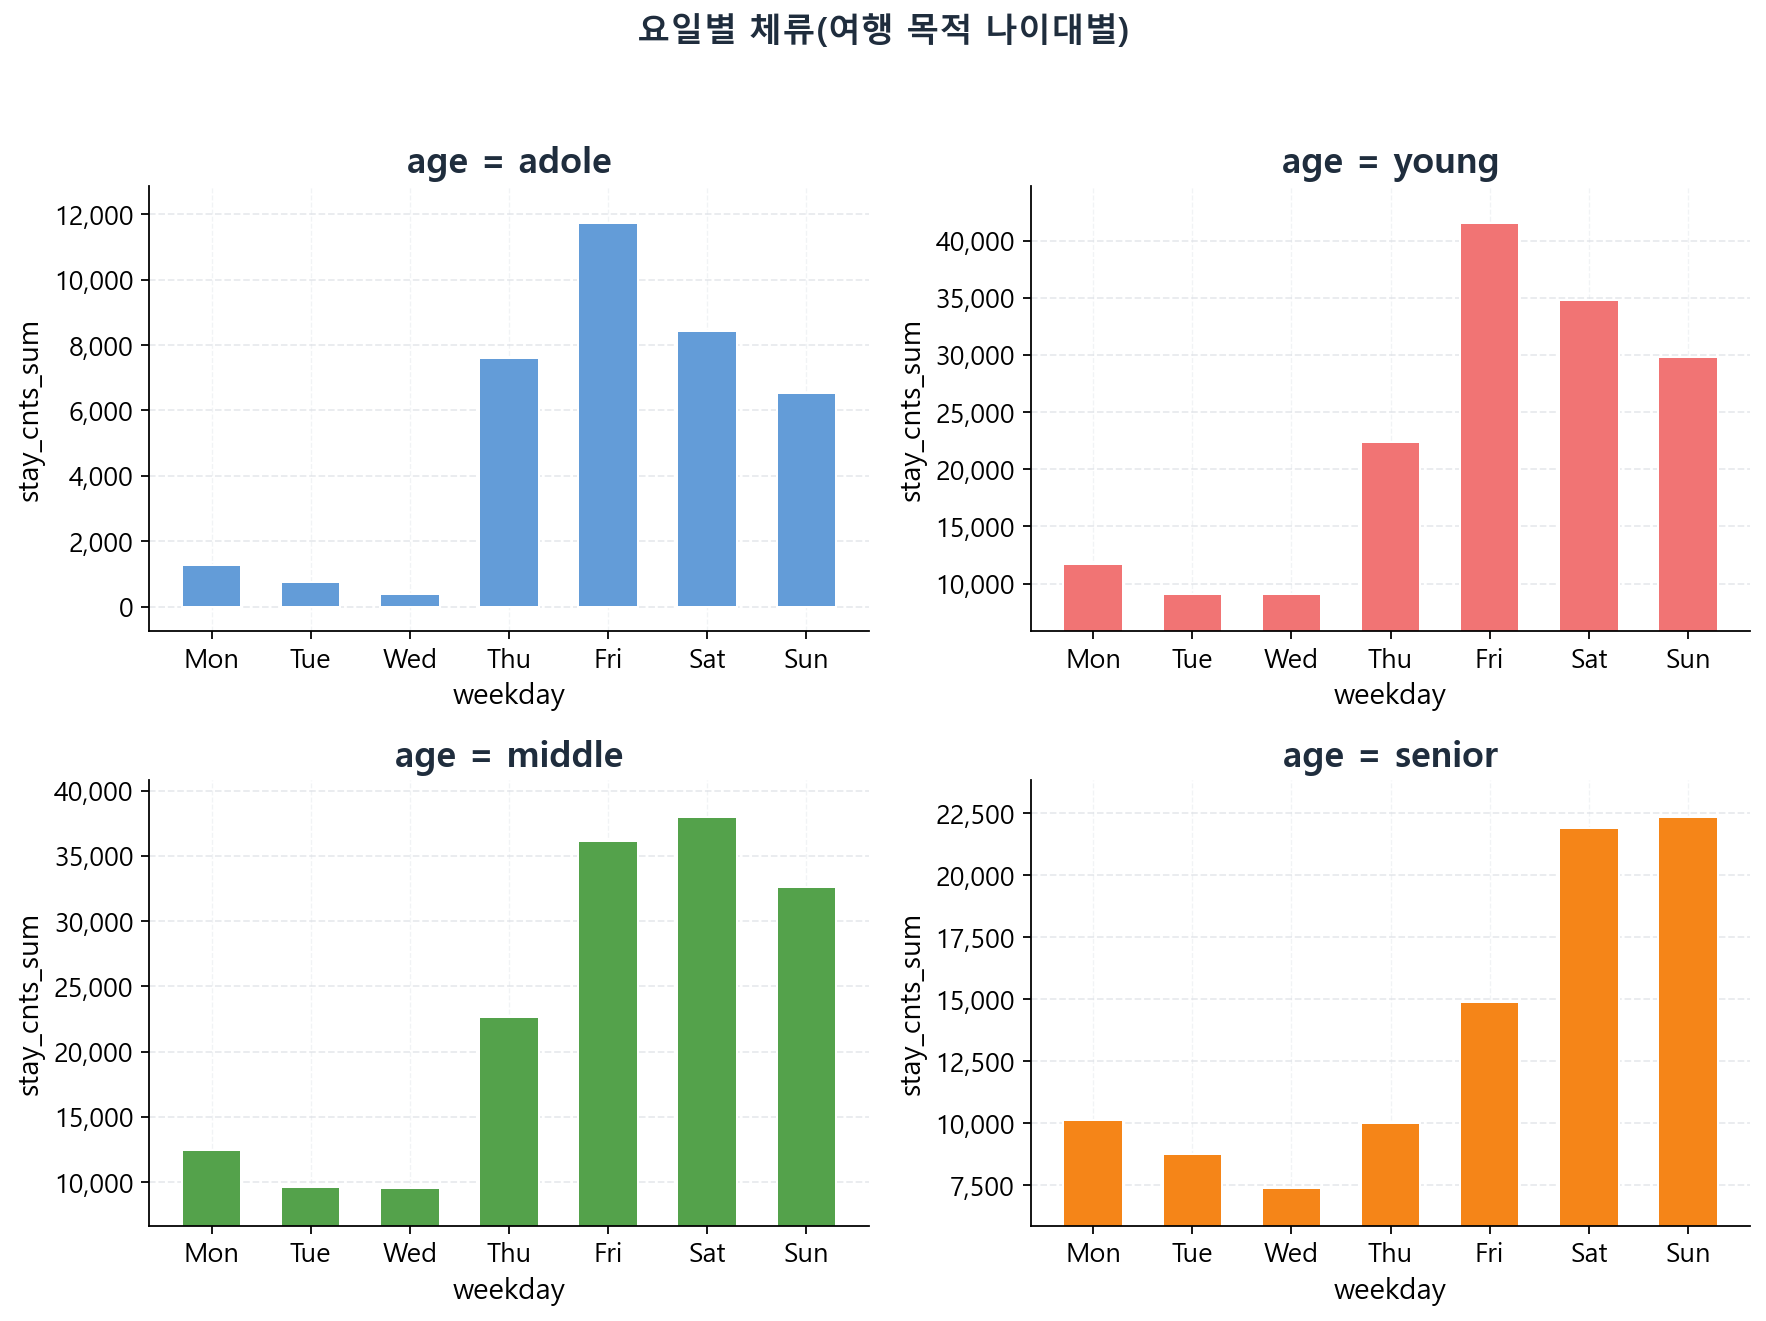

In [402]:
set_ppt_style(base_size=12)
fig3, _ = plot_stay_weekday_by_age_bars(
    stay_agg[stay_agg['purpose_grp'] == '여행'],
    title="요일별 체류(여행 목적 나이대별)",
    hdong_cd=4713035000,
    ages=("adole", "young", "middle", "senior"),
    y_zoom="per_age"
)
plt.show()